#Block 2 — Step 1: Data Understanding and Initial Inspection

In [6]:
# =============================
# Block 2 — Step 1: Data Understanding and Initial Inspection
# =============================

import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("insurance.csv")

# Basic overview
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

# Missing values
missing_df = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="missing_count", ascending=False)

print("\nMissing value summary:")
display(missing_df)

# Duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Summary statistics
print("\nSummary statistics:")
display(df.describe().T)

# Unique values in each column
unique_values_df = pd.DataFrame({
    "column": df.columns,
    "unique_values": [df[col].nunique() for col in df.columns]
}).sort_values(by="unique_values")

print("\nUnique value count per column:")
display(unique_values_df)

# Column groups
target_col = "PremiumPrice"

binary_cols = [
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "NumberOfMajorSurgeries",
    "PremiumPrice"
]

feature_cols = [col for col in df.columns if col != target_col]

print("\nTarget column:", target_col)
print("\nFeature columns:")
print(feature_cols)

print("\nBinary columns:")
print(binary_cols)

print("\nNumeric columns:")
print(numeric_cols)

# Validate binary columns
binary_validation = {}
for col in binary_cols:
    binary_validation[col] = sorted(df[col].dropna().unique().tolist())

binary_validation_df = pd.DataFrame({
    "column": binary_validation.keys(),
    "unique_values": binary_validation.values()
})

print("\nBinary column validation:")
display(binary_validation_df)

# Numeric range check
range_check_df = pd.DataFrame({
    "column": numeric_cols,
    "min": [df[col].min() for col in numeric_cols],
    "max": [df[col].max() for col in numeric_cols],
    "mean": [df[col].mean() for col in numeric_cols],
    "median": [df[col].median() for col in numeric_cols]
})

print("\nRange check for numeric columns:")
display(range_check_df)

# Condition prevalence
condition_prevalence = (df[binary_cols].mean() * 100).round(2).sort_values(ascending=False)
condition_prevalence_df = condition_prevalence.reset_index()
condition_prevalence_df.columns = ["condition", "percent_with_value_1"]

print("\nCondition prevalence (% of people with condition = 1):")
display(condition_prevalence_df)

# Final observations
print("\nFinal quick observations:")
print(f"- Total rows: {df.shape[0]}")
print(f"- Total columns: {df.shape[1]}")
print(f"- Missing values in dataset: {df.isnull().sum().sum()}")
print(f"- Duplicate rows in dataset: {duplicate_count}")
print(f"- Target variable: {target_col}")
print(f"- PremiumPrice unique values: {df['PremiumPrice'].nunique()}")

Shape of dataset: (986, 11)

Columns in dataset:
['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'PremiumPrice']

First 5 rows:


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000



Data types:


,dtype
Age,int64
Diabetes,int64
BloodPressureProblems,int64
AnyTransplants,int64
AnyChronicDiseases,int64
Height,int64
Weight,int64
KnownAllergies,int64
HistoryOfCancerInFamily,int64
NumberOfMajorSurgeries,int64



Missing value summary:


...


Range check for numeric columns:


,column,min,max,mean,median
0,Age,18,66,41.745436,42.0
1,Height,145,188,168.182556,168.0
2,Weight,51,132,76.950304,75.0
3,NumberOfMajorSurgeries,0,3,0.667343,1.0
4,PremiumPrice,15000,40000,24336.713996,23000.0



Condition prevalence (% of people with condition = 1):


,condition,percent_with_value_1
0,BloodPressureProblems,46.86
1,Diabetes,41.99
2,KnownAllergies,21.50
3,AnyChronicDiseases,18.05
4,HistoryOfCancerInFamily,11.76
5,AnyTransplants,5.58



Final quick observations:
- Total rows: 986
- Total columns: 11
- Missing values in dataset: 0
- Duplicate rows in dataset: 0
- Target variable: PremiumPrice
- PremiumPrice unique values: 24


### Insights from Step 1

1. The dataset contains **986 rows and 11 columns**, which is a manageable size for completing the project end to end, including EDA, hypothesis testing, machine learning modeling, and deployment.

2. The target variable is **PremiumPrice**, so this project is a **supervised regression problem**.

3. The dataset is structurally very clean:
   - **No missing values**
   - **No duplicate rows**
   - All columns are numeric
   - All binary medical-condition columns correctly contain only **0 and 1**

4. The data includes three major types of predictors:
   - **Demographic/body variables**: Age, Height, Weight
   - **Medical risk indicators**: Diabetes, BloodPressureProblems, AnyTransplants, AnyChronicDiseases, KnownAllergies, HistoryOfCancerInFamily
   - **Medical history intensity**: NumberOfMajorSurgeries

5. The average customer profile in this dataset is approximately:
   - **42 years old**
   - **168 cm** in height
   - **77 kg** in weight
   - premium around **24,337**
   - median premium is **23,000**

6. Among the binary health indicators, the most common conditions are:
   - **BloodPressureProblems (46.86%)**
   - **Diabetes (41.99%)**
   This suggests that these variables may play an important role in premium prediction and should be examined carefully in EDA and modeling.

7. Some medical conditions are relatively rare:
   - **AnyTransplants (5.58%)**
   - **HistoryOfCancerInFamily (11.76%)**
   These may still be important high-impact predictors even though they are less frequent.

8. The variable **NumberOfMajorSurgeries** ranges from **0 to 3**, with median value **1**, making it a strong candidate for group-wise premium comparison and hypothesis testing.

9. The target variable **PremiumPrice** has only **24 unique values**, which means premium values are not fully continuous and may be banded into pricing slabs. This is important because the model may partly learn premium bands rather than perfectly smooth pricing behavior.

10. Since both **Height** and **Weight** are available, we can create an important engineered feature:
   - **BMI = Weight / (Height in meters)^2**
   This will likely be more meaningful than using height and weight separately in some analyses.

11. One important correction to the project brief:
   - the brief mentions smoker-related hypothesis testing,
   - but the actual dataset does **not** contain a smoker column,
   - so all further analysis must be based only on the variables actually present in the dataset.
  

#Block 2 — Step 2: Univariate Analysis and Distributions

Numeric Summary Statistics


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
Age,986.0,41.745436,13.963371,18.0,30.0,42.0,53.0,66.0,42.0,0.029895,-1.131720
Height,986.0,168.182556,10.098155,145.0,161.0,168.0,176.0,188.0,168.0,-0.179788,-0.761975
Weight,986.0,76.950304,14.265096,51.0,67.0,75.0,87.0,132.0,75.0,0.666726,0.610280
NumberOfMajorSurgeries,986.0,0.667343,0.749205,0.0,0.0,1.0,1.0,3.0,1.0,0.861334,0.066209
PremiumPrice,986.0,24336.713996,6248.184382,15000.0,21000.0,23000.0,28000.0,40000.0,23000.0,0.097639,-0.452895


IQR-Based Outlier Summary


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,Age,30.0,53.0,23.0,-4.5,87.5,0,0.00
1,Height,161.0,176.0,15.0,138.5,198.5,0,0.00
2,Weight,67.0,87.0,20.0,37.0,117.0,16,1.62
3,NumberOfMajorSurgeries,0.0,1.0,1.0,-1.5,2.5,16,1.62
4,PremiumPrice,21000.0,28000.0,7000.0,10500.0,38500.0,6,0.61


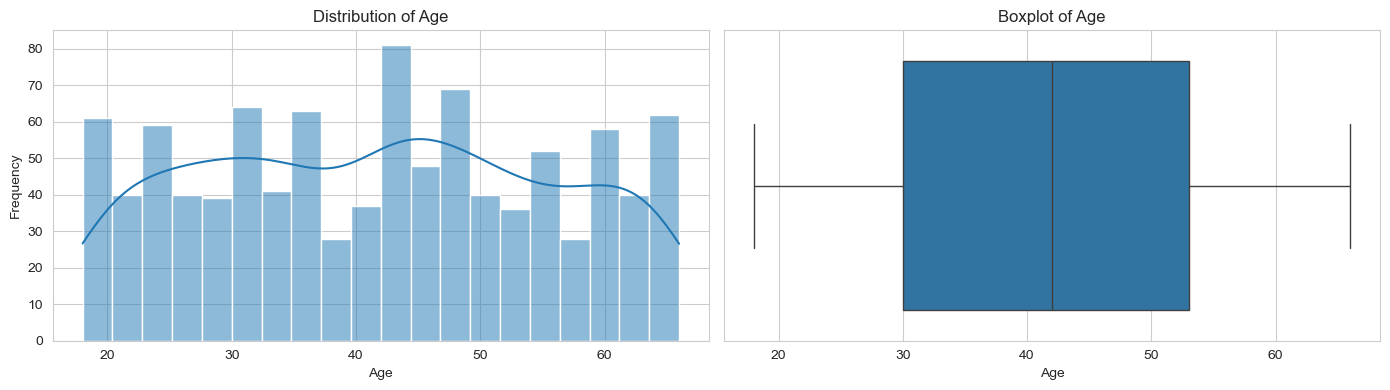

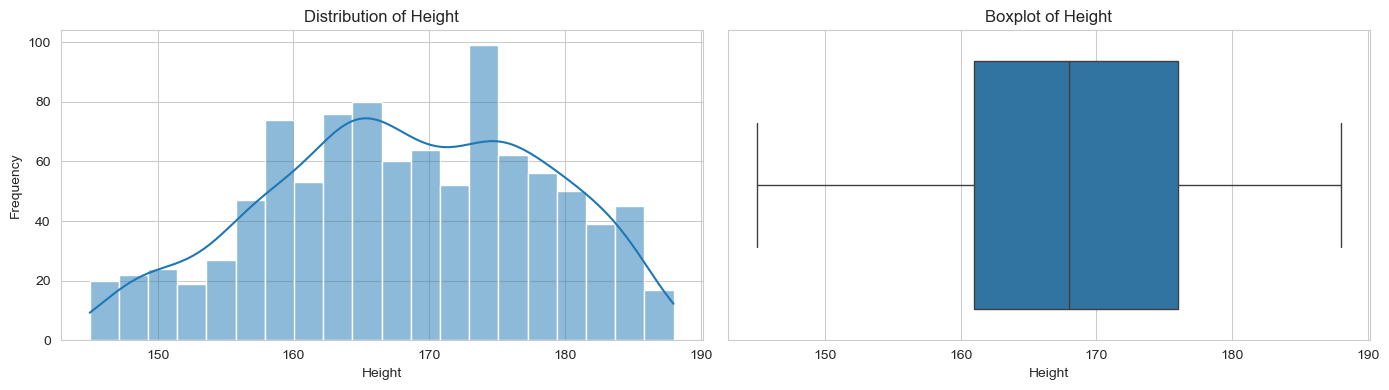

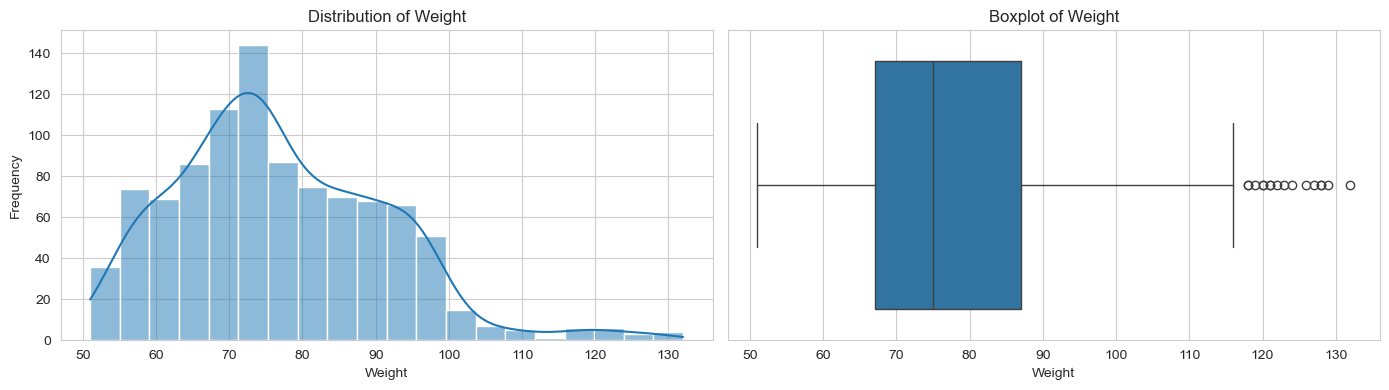

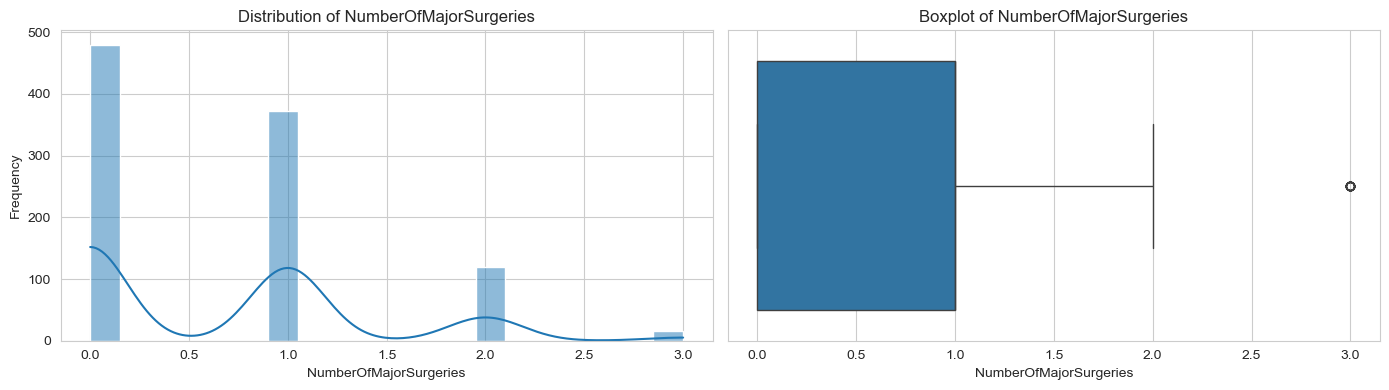

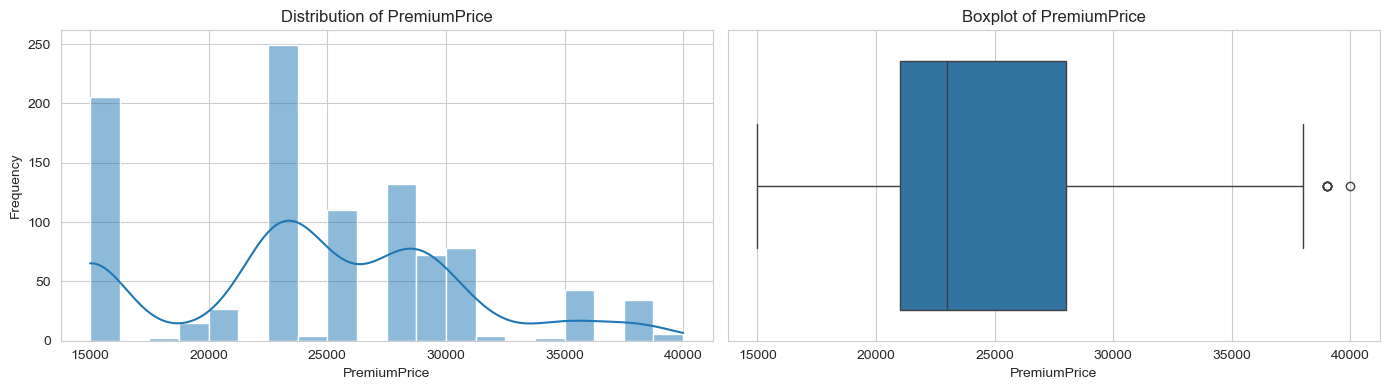

Binary Variable Summary


,Condition,Count_1,Percent_1,Count_0,Percent_0
0,BloodPressureProblems,462,46.86,524,53.14
1,Diabetes,414,41.99,572,58.01
2,KnownAllergies,212,21.50,774,78.50
3,AnyChronicDiseases,178,18.05,808,81.95
4,HistoryOfCancerInFamily,116,11.76,870,88.24
5,AnyTransplants,55,5.58,931,94.42


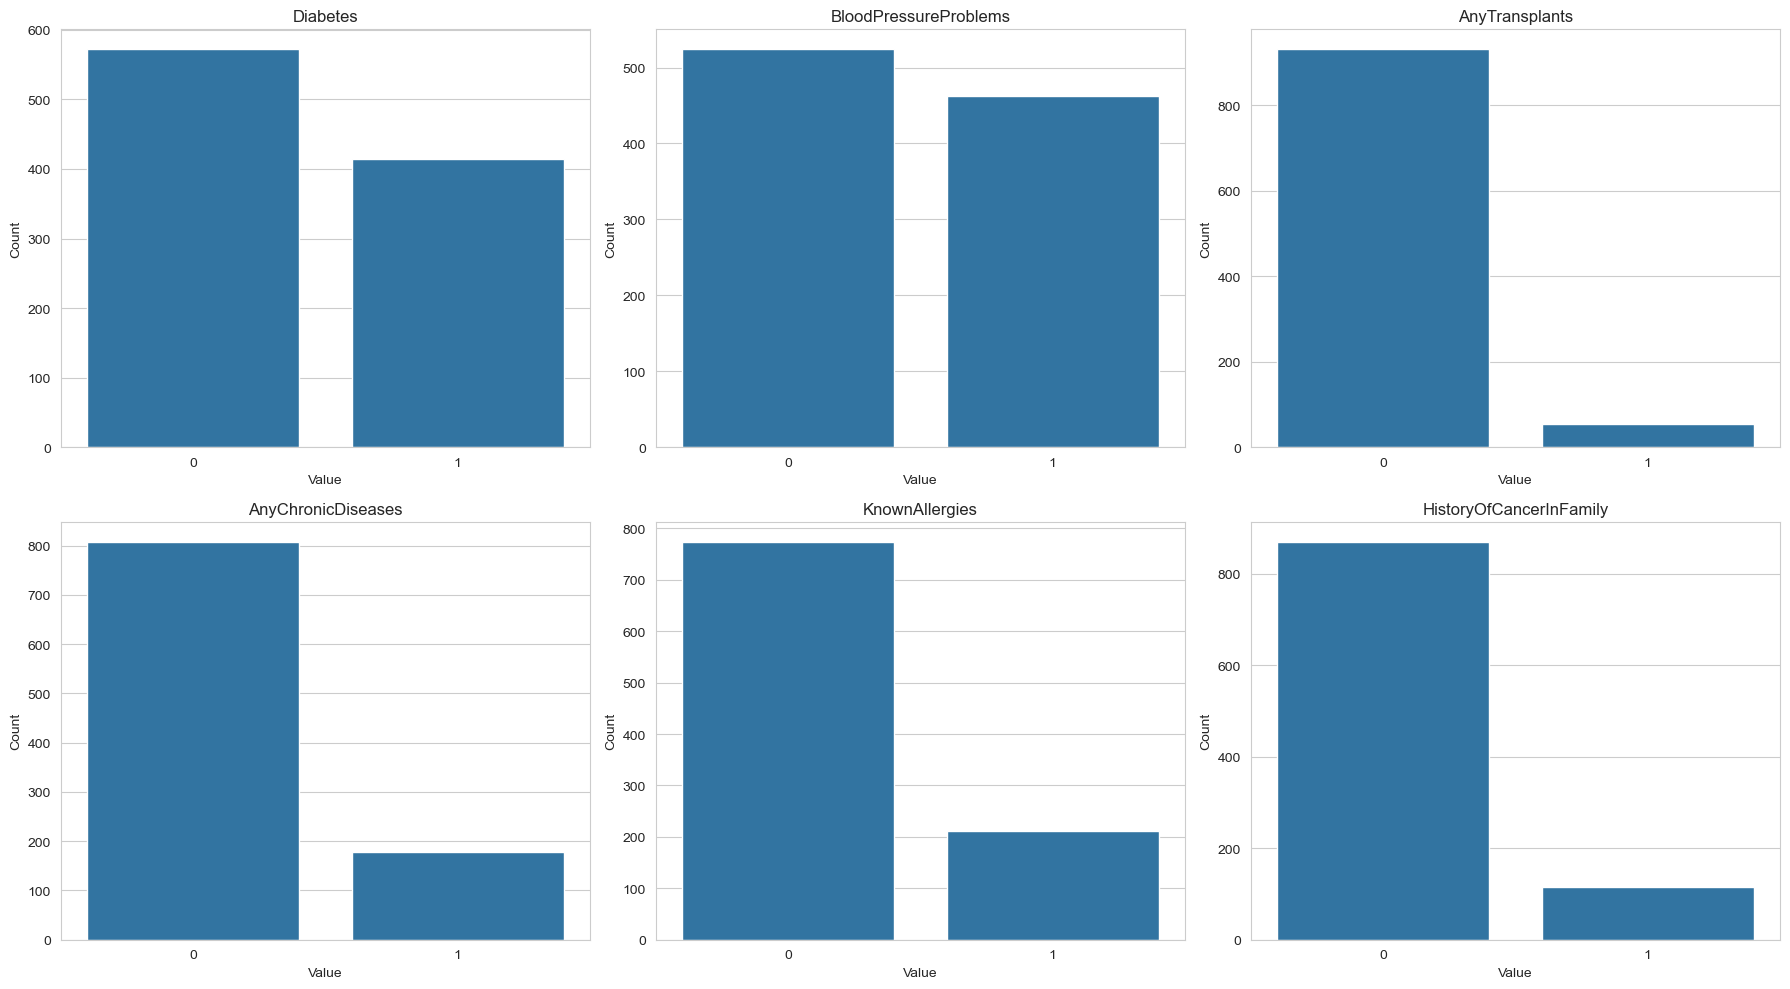

Frequency Distribution: NumberOfMajorSurgeries


,count,percent
NumberOfMajorSurgeries,,
0,479,48.58
1,372,37.73
2,119,12.07
3,16,1.62


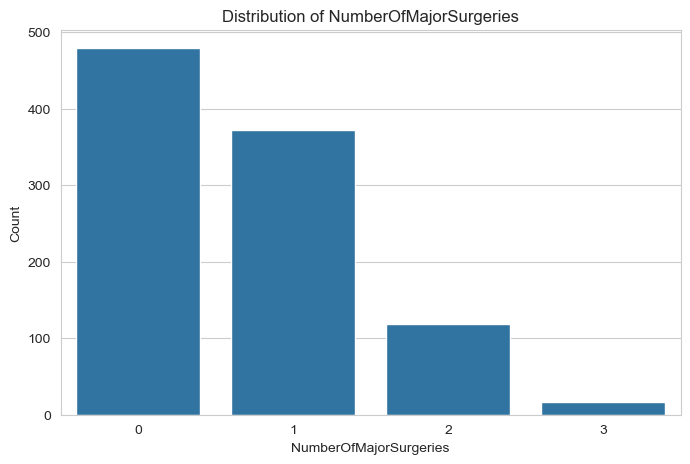

PremiumPrice Frequency Distribution


,count,percent
PremiumPrice,,
15000,202,20.49
16000,3,0.30
17000,1,0.10
18000,2,0.20
19000,15,1.52
20000,1,0.10
21000,26,2.64
22000,1,0.10
23000,249,25.25


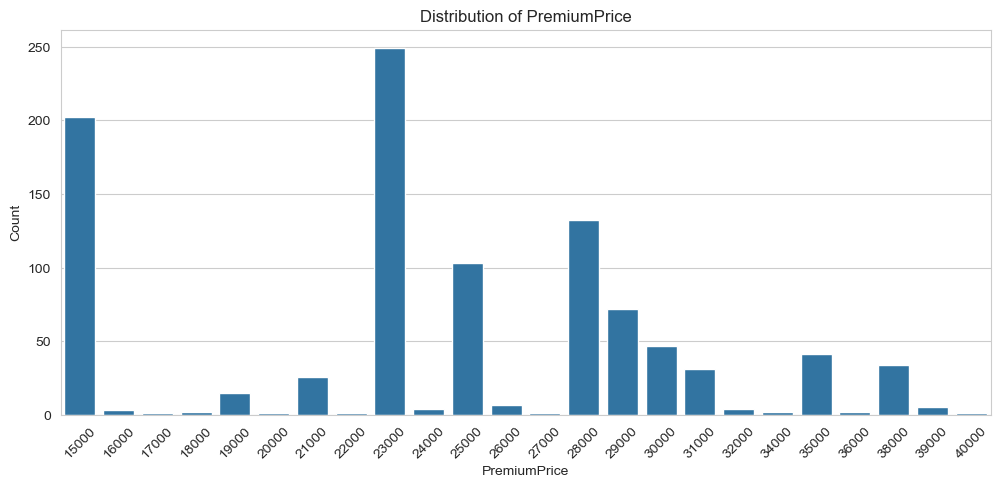

Top Premium Slabs


,PremiumPrice,count,percent
0,23000,249,25.25
1,15000,202,20.49
2,28000,132,13.39
3,25000,103,10.45
4,29000,72,7.30
5,30000,47,4.77
6,35000,41,4.16
7,38000,34,3.45
8,31000,31,3.14
9,21000,26,2.64


In [7]:
# ============================================================
# Block 2 — Step 2: Univariate Analysis and Distributions
# Assumption: df is already loaded in Step 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Basic validation
# -----------------------------
required_cols = [
    "Age", "Diabetes", "BloodPressureProblems", "AnyTransplants",
    "AnyChronicDiseases", "Height", "Weight", "KnownAllergies",
    "HistoryOfCancerInFamily", "NumberOfMajorSurgeries", "PremiumPrice"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"These required columns are missing from df: {missing_cols}")

# -----------------------------
# 2. Column groups
# -----------------------------
numeric_cols = ["Age", "Height", "Weight", "NumberOfMajorSurgeries", "PremiumPrice"]
binary_cols = [
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

# -----------------------------
# 3. Plot settings
# -----------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# -----------------------------
# 4. Numeric summary statistics
# -----------------------------
numeric_summary = df[numeric_cols].describe().T
numeric_summary["median"] = df[numeric_cols].median()
numeric_summary["skewness"] = df[numeric_cols].skew()
numeric_summary["kurtosis"] = df[numeric_cols].kurtosis()

print("Numeric Summary Statistics")
display(numeric_summary)

# -----------------------------
# 5. IQR-based outlier summary
# -----------------------------
outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percent = round((outlier_count / len(df)) * 100, 2)

    outlier_rows.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_percent
    })

outlier_df = pd.DataFrame(outlier_rows)

print("IQR-Based Outlier Summary")
display(outlier_df)

# -----------------------------
# 6. Distribution plots for numeric columns
# -----------------------------
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col], kde=True, bins=20, ax=axes[0])
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

# -----------------------------
# 7. Binary variable summary
# -----------------------------
binary_summary = pd.DataFrame({
    "Condition": binary_cols,
    "Count_1": [int(df[col].sum()) for col in binary_cols],
    "Percent_1": [round(df[col].mean() * 100, 2) for col in binary_cols],
    "Count_0": [int((df[col] == 0).sum()) for col in binary_cols],
    "Percent_0": [round((df[col] == 0).mean() * 100, 2) for col in binary_cols]
}).sort_values(by="Percent_1", ascending=False).reset_index(drop=True)

print("Binary Variable Summary")
display(binary_summary)

# -----------------------------
# 8. Bar plots for binary variables
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    value_counts = df[col].value_counts().sort_index()
    sns.barplot(x=value_counts.index.astype(str), y=value_counts.values, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

# -----------------------------
# 9. Frequency distribution: NumberOfMajorSurgeries
# -----------------------------
surgery_freq = df["NumberOfMajorSurgeries"].value_counts().sort_index().to_frame("count")
surgery_freq["percent"] = round((surgery_freq["count"] / len(df)) * 100, 2)

print("Frequency Distribution: NumberOfMajorSurgeries")
display(surgery_freq)

plt.figure(figsize=(8, 5))
sns.countplot(x="NumberOfMajorSurgeries", data=df)
plt.title("Distribution of NumberOfMajorSurgeries")
plt.xlabel("NumberOfMajorSurgeries")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 10. Premium price frequency distribution
# -----------------------------
premium_freq = (
    df["PremiumPrice"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)
premium_freq["percent"] = round((premium_freq["count"] / len(df)) * 100, 2)

print("PremiumPrice Frequency Distribution")
display(premium_freq)

plt.figure(figsize=(12, 5))
sns.countplot(x="PremiumPrice", data=df, order=sorted(df["PremiumPrice"].unique()))
plt.title("Distribution of PremiumPrice")
plt.xlabel("PremiumPrice")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 11. Top premium slabs
# -----------------------------
top_premium_slabs = (
    df["PremiumPrice"]
    .value_counts()
    .reset_index()
)
top_premium_slabs.columns = ["PremiumPrice", "count"]
top_premium_slabs["percent"] = round((top_premium_slabs["count"] / len(df)) * 100, 2)

print("Top Premium Slabs")
display(top_premium_slabs.head(10))

### Insights from Step 2

#### 1. Numeric variables are mostly clean and stable
- **Age** ranges from **18 to 66**, with mean **41.75** and median **42**
- **Height** ranges from **145 to 188 cm**, with mean **168.18 cm**
- **Weight** ranges from **51 to 132 kg**, with mean **76.95 kg** and median **75 kg**
- **NumberOfMajorSurgeries** ranges from **0 to 3**, with mean **0.67** and median **1**
- **PremiumPrice** ranges from **15,000 to 40,000**, with mean **24,336.71** and median **23,000**

This shows that the dataset is well-structured and does not have extreme instability in the core variables.

---

#### 2. Outliers are present, but not severe
Based on the IQR method:
- **Age:** 0 outliers
- **Height:** 0 outliers
- **Weight:** 16 outliers (**1.62%**)
- **NumberOfMajorSurgeries:** 16 outliers (**1.62%**)
- **PremiumPrice:** 6 outliers (**0.61%**)

This indicates that the dataset is generally clean, so aggressive outlier removal is not required at this stage. The few outliers may represent genuine high-risk profiles rather than data errors.

---

#### 3. Weight and surgeries show right-skewed behavior
Among the numeric variables, **Weight** and **NumberOfMajorSurgeries** are more right-skewed than Age and Height. This means a small number of individuals have relatively high weight or unusually high surgery counts.

These variables may later show a strong effect on premium and should be examined carefully in bivariate analysis.

---

#### 4. PremiumPrice behaves like a banded pricing target
A key finding is that **PremiumPrice has only 24 unique values**, which suggests that the insurer is not assigning fully continuous premiums. Instead, premiums appear to be assigned in **pricing slabs or bands**.

The most common premium values are:
- **23,000** → **249 records (25.25%)**
- **15,000** → **202 records (20.49%)**
- **28,000** → **132 records (13.39%)**
- **25,000** → **103 records (10.45%)**

This is a major business and modeling insight. The model may learn slab-based pricing behavior rather than a perfectly smooth numeric relationship.

---

#### 5. Surgeries are concentrated in lower categories
The distribution of `NumberOfMajorSurgeries` is:
- **0 surgeries:** 479 records (**48.58%**)
- **1 surgery:** 372 records (**37.73%**)
- **2 surgeries:** 119 records (**12.07%**)
- **3 surgeries:** 16 records (**1.62%**)

Most individuals fall in the **0 or 1 surgery** categories. The higher surgery groups are less frequent, but they are likely to be important in premium differentiation.

---

#### 6. Most common medical risk indicators
The prevalence of binary health conditions is:
- **BloodPressureProblems:** **46.86%**
- **Diabetes:** **41.99%**
- **KnownAllergies:** **21.50%**
- **AnyChronicDiseases:** **18.05%**
- **HistoryOfCancerInFamily:** **11.76%**
- **AnyTransplants:** **5.58%**

The most common conditions are **BloodPressureProblems** and **Diabetes**, which makes them strong candidates for deeper premium analysis.  
Although **AnyTransplants** is rare, it may still act as a high-impact risk factor.

---

#### 7. Business interpretation of the univariate analysis
The univariate patterns suggest that the insurer is likely assigning customers into premium bands based on a combination of:
- demographic and body-related characteristics
- chronic or medical condition indicators
- severity/history features such as surgeries and transplants

This means the next step should focus on identifying which variables actually shift premium levels the most and whether those differences are statistically meaningful.

#Block 2 — Step 3: Bivariate Analysis and Relationship with PremiumPrice

Correlation Matrix


,Age,Height,Weight,NumberOfMajorSurgeries,BMI,PremiumPrice
Age,1.000000,0.039879,-0.018590,0.429181,-0.042027,0.697540
Height,0.039879,1.000000,0.066946,0.037289,-0.504947,0.026910
Weight,-0.018590,0.066946,1.000000,-0.006108,0.820679,0.141507
NumberOfMajorSurgeries,0.429181,0.037289,-0.006108,1.000000,-0.027225,0.264250
BMI,-0.042027,-0.504947,0.820679,-0.027225,1.000000,0.103812
PremiumPrice,0.697540,0.026910,0.141507,0.264250,0.103812,1.000000


Correlation of Features with PremiumPrice


,correlation_with_PremiumPrice
Age,0.697540
NumberOfMajorSurgeries,0.264250
Weight,0.141507
BMI,0.103812
Height,0.026910


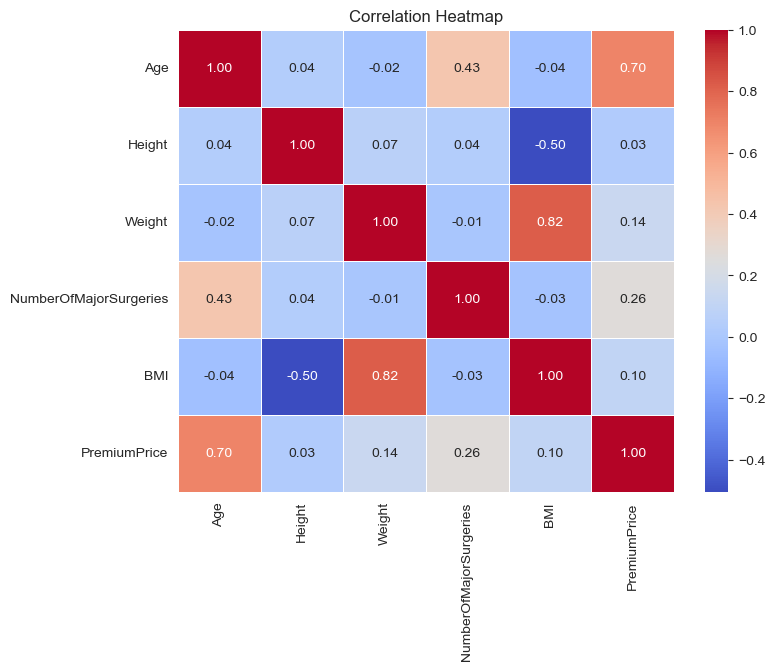

Age Group vs PremiumPrice Summary


,count,mean,median,min,max
AgeGroup,,,,,
18-25,160,16212.50,15000.0,15000,39000
26-35,210,21390.48,23000.0,15000,39000
36-45,208,25485.58,23000.0,17000,38000
46-55,205,28121.95,28000.0,20000,39000
56-66,203,28788.18,28000.0,16000,40000


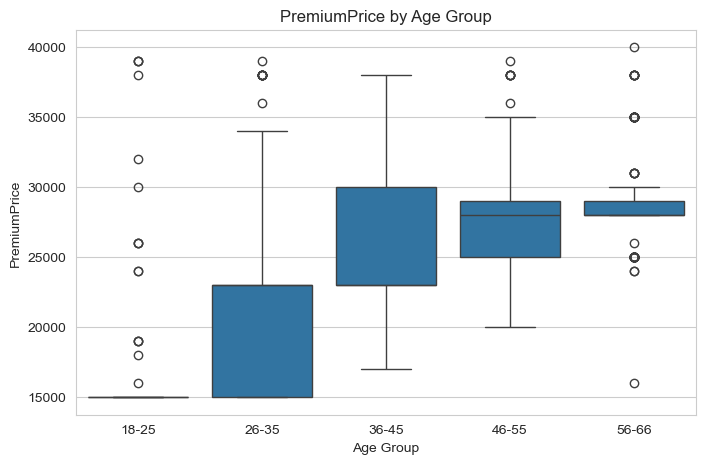

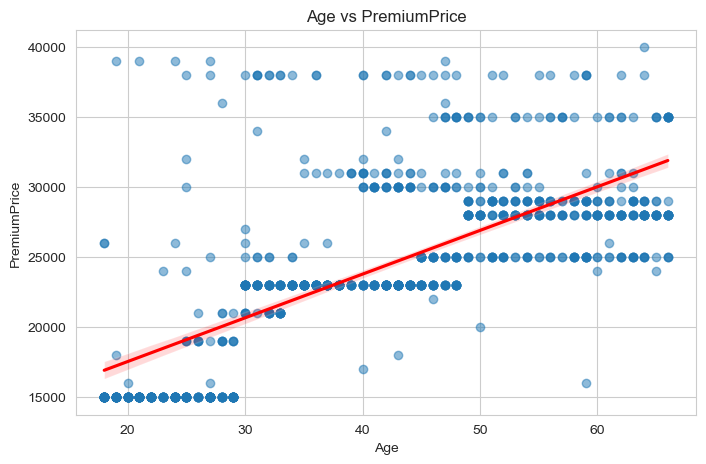

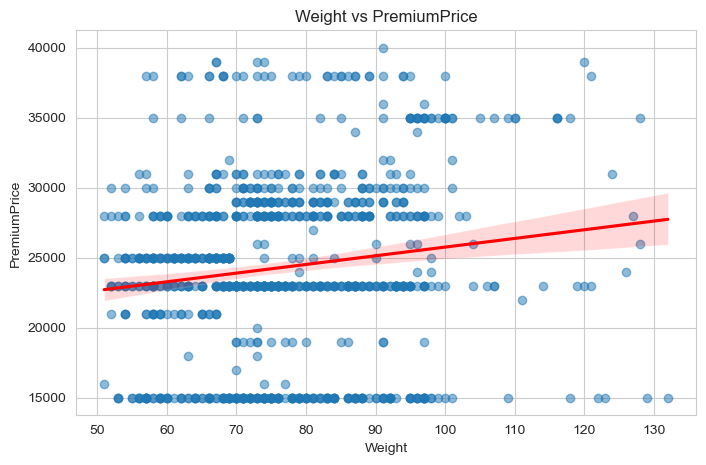

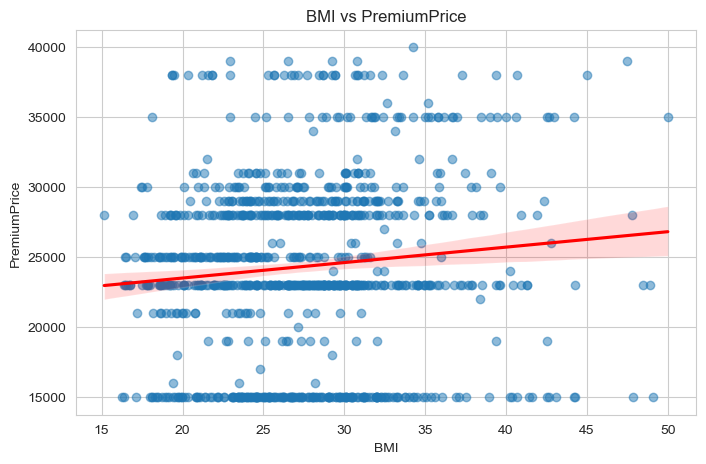

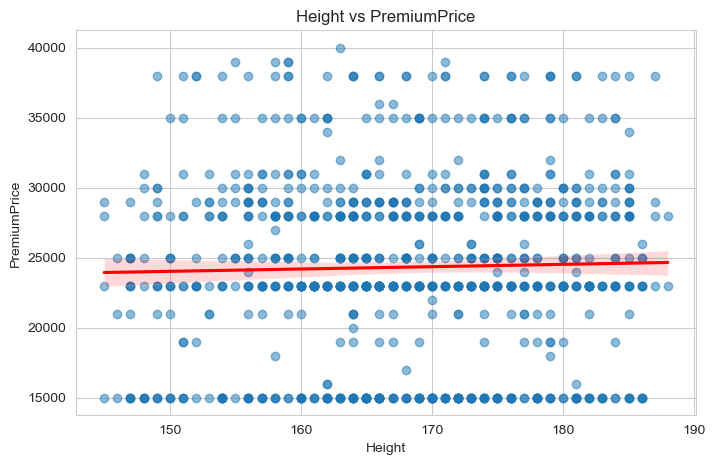

Binary Condition vs PremiumPrice Summary


,Condition,Count_0,Mean_Premium_0,Median_Premium_0,Count_1,Mean_Premium_1,Median_Premium_1,Mean_Difference_1_minus_0
0,AnyTransplants,931,23897.96,23000.0,55,31763.64,38000.0,7865.68
1,AnyChronicDiseases,808,23725.25,23000.0,178,27112.36,28000.0,3387.11
2,BloodPressureProblems,524,23356.87,23000.0,462,25448.05,25000.0,2091.18
3,HistoryOfCancerInFamily,870,24147.13,23000.0,116,25758.62,28000.0,1611.49
4,Diabetes,572,23931.82,23000.0,414,24896.14,25000.0,964.32
5,KnownAllergies,774,24297.16,23000.0,212,24481.13,23000.0,183.97


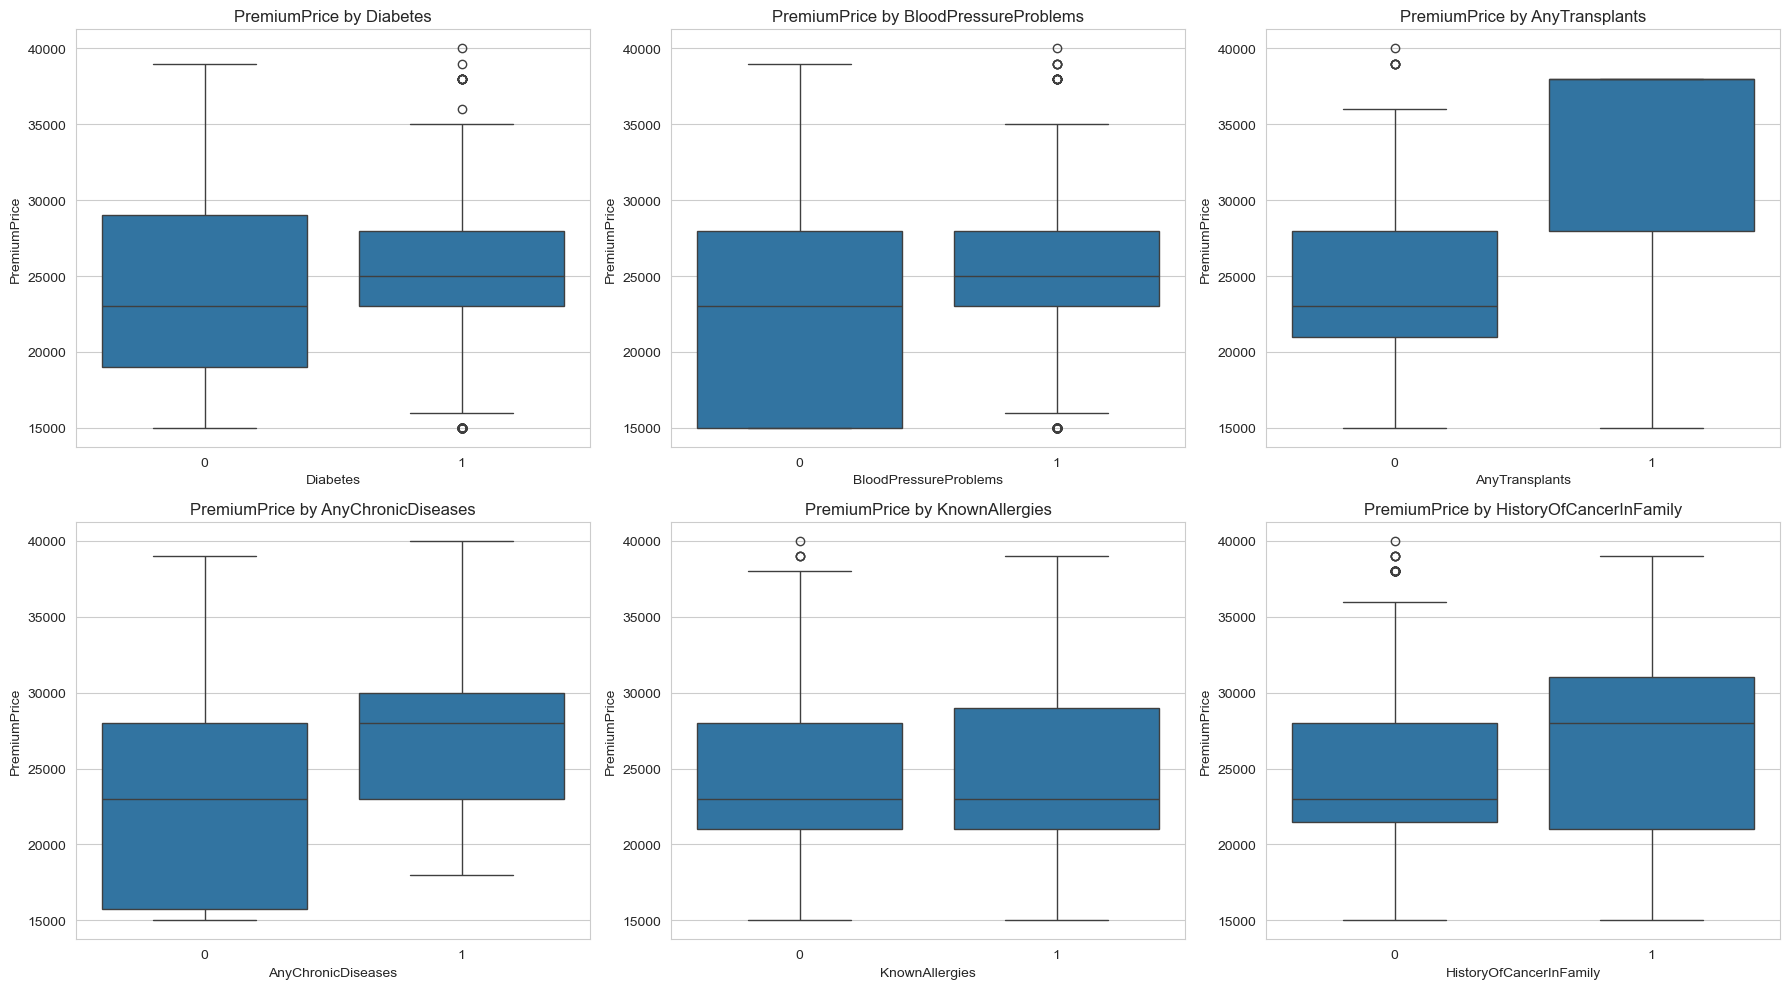

NumberOfMajorSurgeries vs PremiumPrice Summary


,count,mean,median,std,min,max
NumberOfMajorSurgeries,,,,,,
0,479,22968.68,23000.0,6356.98,15000,39000
1,372,24741.94,25000.0,6593.97,15000,39000
2,119,28084.03,28000.0,1175.89,24000,40000
3,16,28000.00,28000.0,0.00,28000,28000


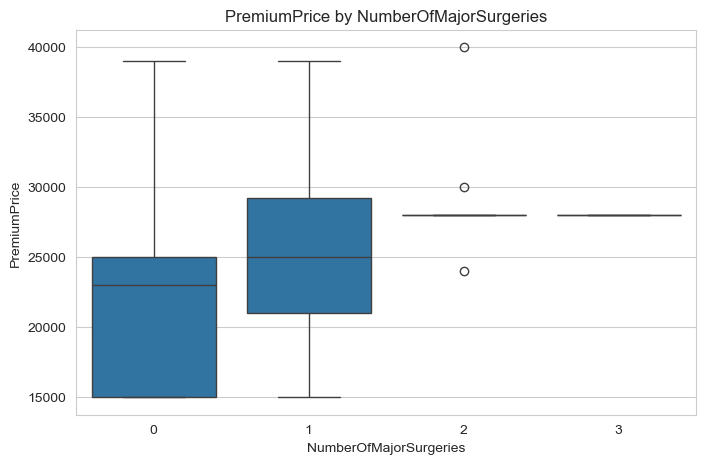

BMI Category vs PremiumPrice Summary


,count,mean,median,std
BMI_Category,,,,
Underweight,39,22666.67,23000.0,5027.99
Normal,319,23711.60,25000.0,5624.93
Overweight,325,24313.85,23000.0,6153.39
Obese,303,25234.32,25000.0,6973.55


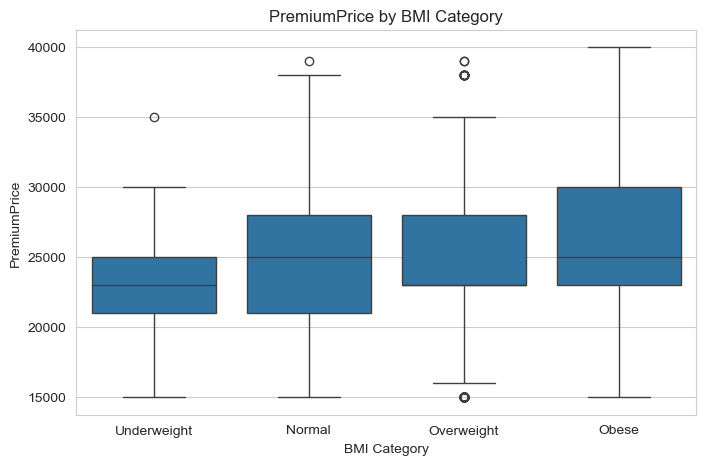

In [8]:
# ============================================================
# Block 2 — Step 3: Bivariate Analysis and Relationship with PremiumPrice
# Assumption: df is already loaded in Step 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Basic validation
# -----------------------------
required_cols = [
    "Age", "Diabetes", "BloodPressureProblems", "AnyTransplants",
    "AnyChronicDiseases", "Height", "Weight", "KnownAllergies",
    "HistoryOfCancerInFamily", "NumberOfMajorSurgeries", "PremiumPrice"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"These required columns are missing from df: {missing_cols}")

# -----------------------------
# 2. Create BMI feature
# -----------------------------
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

# Optional BMI categories for easier business interpretation
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
df["BMI_Category"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

# -----------------------------
# 3. Plot settings
# -----------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

binary_cols = [
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

numeric_cols = ["Age", "Height", "Weight", "NumberOfMajorSurgeries", "BMI", "PremiumPrice"]

# -----------------------------
# 4. Correlation analysis
# -----------------------------
corr_df = df[numeric_cols].corr()

print("Correlation Matrix")
display(corr_df)

target_corr = (
    corr_df["PremiumPrice"]
    .drop("PremiumPrice")
    .sort_values(ascending=False)
    .to_frame("correlation_with_PremiumPrice")
)

print("Correlation of Features with PremiumPrice")
display(target_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# 5. Age group analysis
# -----------------------------
age_bins = [17, 25, 35, 45, 55, 66]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-66"]
df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

age_group_summary = (
    df.groupby("AgeGroup", observed=False)["PremiumPrice"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("Age Group vs PremiumPrice Summary")
display(age_group_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(x="AgeGroup", y="PremiumPrice", data=df, order=age_labels)
plt.title("PremiumPrice by Age Group")
plt.xlabel("Age Group")
plt.ylabel("PremiumPrice")
plt.show()

# -----------------------------
# 6. Scatter plots with regression line
# -----------------------------
scatter_features = ["Age", "Weight", "BMI", "Height"]

for col in scatter_features:
    plt.figure(figsize=(8, 5))
    sns.regplot(x=col, y="PremiumPrice", data=df, scatter_kws={"alpha": 0.5}, line_kws={"color": "red"})
    plt.title(f"{col} vs PremiumPrice")
    plt.xlabel(col)
    plt.ylabel("PremiumPrice")
    plt.show()

# -----------------------------
# 7. Binary condition-wise premium comparison
# -----------------------------
binary_premium_summary = []

for col in binary_cols:
    grp = df.groupby(col)["PremiumPrice"].agg(["count", "mean", "median", "std"]).round(2)
    
    premium_0_mean = grp.loc[0, "mean"]
    premium_1_mean = grp.loc[1, "mean"]
    diff_mean = round(premium_1_mean - premium_0_mean, 2)

    binary_premium_summary.append({
        "Condition": col,
        "Count_0": int(grp.loc[0, "count"]),
        "Mean_Premium_0": premium_0_mean,
        "Median_Premium_0": grp.loc[0, "median"],
        "Count_1": int(grp.loc[1, "count"]),
        "Mean_Premium_1": premium_1_mean,
        "Median_Premium_1": grp.loc[1, "median"],
        "Mean_Difference_1_minus_0": diff_mean
    })

binary_premium_summary_df = (
    pd.DataFrame(binary_premium_summary)
    .sort_values(by="Mean_Difference_1_minus_0", ascending=False)
    .reset_index(drop=True)
)

print("Binary Condition vs PremiumPrice Summary")
display(binary_premium_summary_df)

# Boxplots for binary conditions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.boxplot(x=col, y="PremiumPrice", data=df, ax=axes[i])
    axes[i].set_title(f"PremiumPrice by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("PremiumPrice")

plt.tight_layout()
plt.show()

# -----------------------------
# 8. NumberOfMajorSurgeries vs PremiumPrice
# -----------------------------
surgery_summary = (
    df.groupby("NumberOfMajorSurgeries")["PremiumPrice"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("NumberOfMajorSurgeries vs PremiumPrice Summary")
display(surgery_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(x="NumberOfMajorSurgeries", y="PremiumPrice", data=df)
plt.title("PremiumPrice by NumberOfMajorSurgeries")
plt.xlabel("NumberOfMajorSurgeries")
plt.ylabel("PremiumPrice")
plt.show()

# -----------------------------
# 9. BMI category vs PremiumPrice
# -----------------------------
bmi_category_summary = (
    df.groupby("BMI_Category", observed=False)["PremiumPrice"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("BMI Category vs PremiumPrice Summary")
display(bmi_category_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(x="BMI_Category", y="PremiumPrice", data=df, order=bmi_labels)
plt.title("PremiumPrice by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("PremiumPrice")
plt.show()

### Insights from Step 3

#### 1. Age is the strongest linear driver of premium
The correlation analysis shows that **Age** has the strongest relationship with `PremiumPrice`, with correlation around **0.70**. This is substantially higher than the correlations of Weight, BMI, Height, or NumberOfMajorSurgeries.

Average premium also rises clearly across age groups:
- **18–25:** ~**16,212**
- **26–35:** ~**21,390**
- **36–45:** ~**25,486**
- **46–55:** ~**28,122**
- **56–66:** ~**28,788**

**Interpretation:**  
Premium increases strongly with age, which indicates that age is likely one of the most important variables used in pricing.

---

#### 2. Number of major surgeries has a meaningful positive relationship with premium
`NumberOfMajorSurgeries` has a moderate positive correlation with premium, around **0.26**.

Average premium by surgery count:
- **0 surgeries:** ~**22,969**
- **1 surgery:** ~**24,742**
- **2 surgeries:** ~**28,084**
- **3 surgeries:** ~**28,000**

**Interpretation:**  
Premium rises meaningfully as surgery history increases, especially from 0 to 2 surgeries. This suggests that surgery count captures medical severity and should be an important modeling feature.

---

#### 3. Transplants and chronic diseases show the largest premium jumps among binary health conditions
Comparing mean premium for people with condition = 1 versus condition = 0:

- **AnyTransplants:** increase of ~**7,866**
- **AnyChronicDiseases:** increase of ~**3,387**
- **BloodPressureProblems:** increase of ~**2,091**
- **HistoryOfCancerInFamily:** increase of ~**1,611**
- **Diabetes:** increase of ~**964**
- **KnownAllergies:** increase of only ~**184**

**Interpretation:**  
The strongest premium differentiator among binary conditions is clearly **AnyTransplants**, followed by **AnyChronicDiseases**.  
In contrast, **KnownAllergies** appears to have minimal practical impact on premium.

---

#### 4. Median premiums confirm the same pattern
Median premium shifts are also informative:
- **AnyTransplants = 1:** median premium is **38,000**, compared with **23,000** for non-transplant cases
- **AnyChronicDiseases = 1:** median premium is **28,000**, compared with **23,000**
- **HistoryOfCancerInFamily = 1:** median premium is **28,000**, compared with **23,000**
- **Diabetes = 1** and **BloodPressureProblems = 1:** both tend to shift the median upward toward **25,000**

**Interpretation:**  
This confirms that some medical conditions are not just causing small numeric differences but may actually move people into higher premium slabs.

---

#### 5. Weight and BMI have only weak positive relationships with premium
The correlations with premium are relatively small:
- **Weight:** ~**0.14**
- **BMI:** ~**0.10**
- **Height:** ~**0.03**

Average premium by BMI category:
- **Underweight:** ~**22,667**
- **Normal:** ~**23,712**
- **Overweight:** ~**24,314**
- **Obese:** ~**25,234**

**Interpretation:**  
BMI and Weight do matter somewhat, but their direct relationship with premium is much weaker than Age or major medical-history variables.  
Height has almost no direct relationship with premium.

---

#### 6. BMI is still useful as an engineered feature
Even though BMI’s linear correlation with premium is not strong, the category-wise analysis shows a gradual increase in average premium from underweight to obese individuals.

**Interpretation:**  
BMI is still worth keeping as a derived feature because it combines Height and Weight into a more clinically meaningful risk indicator than either variable alone.

---

#### 7. Premium appears to be influenced more by medical severity than by simple body measurements
The strongest premium changes are associated with:
- **Age**
- **NumberOfMajorSurgeries**
- **AnyTransplants**
- **AnyChronicDiseases**
- **BloodPressureProblems**

The weaker relationships are seen for:
- **Height**
- **Weight**
- **KnownAllergies**

**Interpretation:**  
This suggests the insurer is primarily pricing based on indicators of **medical severity and long-term health risk**, rather than body size alone.

---

#### 8. Business takeaway from bivariate analysis
The bivariate analysis suggests that premium pricing in this dataset is driven mainly by:
1. **Age-based risk**
2. **Medical history severity**, especially surgeries and transplants
3. **Chronic condition burden**
4. To a lesser extent, **body composition**

This is an important foundation for the next phase, because the hypothesis testing should now formally check whether these observed premium differences are statistically significant.

#Block 2 — Step 4: Hypothesis Testing and Statistical Validation

In [10]:
# ============================================================
# Block 2 — Step 4: Hypothesis Testing and Statistical Validation
# Assumption: df is already loaded in Step 1
# ============================================================

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm

# -----------------------------
# 1. Basic validation
# -----------------------------
required_cols = [
    "Age", "Diabetes", "BloodPressureProblems", "AnyTransplants",
    "AnyChronicDiseases", "Height", "Weight", "KnownAllergies",
    "HistoryOfCancerInFamily", "NumberOfMajorSurgeries", "PremiumPrice"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"These required columns are missing from df: {missing_cols}")

# -----------------------------
# 2. Create BMI and BMI category if not already created
# -----------------------------
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

if "BMI_Category" not in df.columns:
    bmi_bins = [0, 18.5, 25, 30, 100]
    bmi_labels = ["Underweight", "Normal", "Overweight", "Obese"]
    df["BMI_Category"] = pd.cut(df["BMI"], bins=bmi_bins, labels=bmi_labels, right=False)

binary_cols = [
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily"
]

# ============================================================
# 3. Welch's t-tests for binary health conditions vs PremiumPrice
# ============================================================
ttest_results = []

for col in binary_cols:
    group_0 = df.loc[df[col] == 0, "PremiumPrice"]
    group_1 = df.loc[df[col] == 1, "PremiumPrice"]

    # Levene test for equal variance check
    levene_stat, levene_p = stats.levene(group_0, group_1)

    # Use Welch's t-test when variances are unequal
    t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

    ttest_results.append({
        "Variable": col,
        "Mean_Premium_0": round(group_0.mean(), 2),
        "Mean_Premium_1": round(group_1.mean(), 2),
        "Mean_Difference_1_minus_0": round(group_1.mean() - group_0.mean(), 2),
        "Levene_p_value": round(levene_p, 6),
        "T_statistic": round(t_stat, 4),
        "P_value": p_value,
        "Significant_at_5%": "Yes" if p_value < 0.05 else "No"
    })

ttest_results_df = pd.DataFrame(ttest_results).sort_values(by="P_value").reset_index(drop=True)

print("Welch's T-Test Results: Binary Variables vs PremiumPrice")
display(ttest_results_df)

# ============================================================
# 4. One-way ANOVA: NumberOfMajorSurgeries vs PremiumPrice
# ============================================================
surgery_groups = [
    group["PremiumPrice"].values
    for _, group in df.groupby("NumberOfMajorSurgeries")
]

anova_surgery_stat, anova_surgery_p = stats.f_oneway(*surgery_groups)

surgery_summary = (
    df.groupby("NumberOfMajorSurgeries")["PremiumPrice"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Premium Summary by NumberOfMajorSurgeries")
display(surgery_summary)

anova_surgery_result = pd.DataFrame({
    "Test": ["ANOVA: PremiumPrice across NumberOfMajorSurgeries groups"],
    "F_statistic": [round(anova_surgery_stat, 4)],
    "P_value": [anova_surgery_p],
    "Significant_at_5%": ["Yes" if anova_surgery_p < 0.05 else "No"]
})

print("ANOVA Result: NumberOfMajorSurgeries vs PremiumPrice")
display(anova_surgery_result)

# ============================================================
# 5. One-way ANOVA: BMI Category vs PremiumPrice
# ============================================================
bmi_groups = [
    group["PremiumPrice"].values
    for _, group in df.groupby("BMI_Category", observed=False)
]

anova_bmi_stat, anova_bmi_p = stats.f_oneway(*bmi_groups)

bmi_summary = (
    df.groupby("BMI_Category", observed=False)["PremiumPrice"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("Premium Summary by BMI Category")
display(bmi_summary)

anova_bmi_result = pd.DataFrame({
    "Test": ["ANOVA: PremiumPrice across BMI categories"],
    "F_statistic": [round(anova_bmi_stat, 4)],
    "P_value": [anova_bmi_p],
    "Significant_at_5%": ["Yes" if anova_bmi_p < 0.05 else "No"]
})

print("ANOVA Result: BMI Category vs PremiumPrice")
display(anova_bmi_result)

# ============================================================
# 6. Chi-square test: AnyChronicDiseases vs HistoryOfCancerInFamily
# ============================================================
chi_table = pd.crosstab(df["AnyChronicDiseases"], df["HistoryOfCancerInFamily"])
chi2_stat, chi2_p, chi2_dof, chi2_expected = stats.chi2_contingency(chi_table)

print("Contingency Table: AnyChronicDiseases vs HistoryOfCancerInFamily")
display(chi_table)

chi_square_result = pd.DataFrame({
    "Test": ["Chi-square: AnyChronicDiseases vs HistoryOfCancerInFamily"],
    "Chi2_statistic": [round(chi2_stat, 4)],
    "Degrees_of_freedom": [chi2_dof],
    "P_value": [chi2_p],
    "Significant_at_5%": ["Yes" if chi2_p < 0.05 else "No"]
})

print("Chi-Square Test Result")
display(chi_square_result)

# ============================================================
# 7. Regression-based statistical significance check
# ============================================================
regression_features = [
    "Age",
    "BMI",
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "KnownAllergies",
    "HistoryOfCancerInFamily",
    "NumberOfMajorSurgeries"
]

X = df[regression_features].copy()
X = sm.add_constant(X)
y = df["PremiumPrice"]

ols_model = sm.OLS(y, X).fit()

ols_summary_df = pd.DataFrame({
    "Feature": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P_value": ols_model.pvalues.values,
    "Significant_at_5%": ["Yes" if p < 0.05 else "No" for p in ols_model.pvalues.values]
})

print("OLS Regression Coefficients and Significance")
display(ols_summary_df)

print(f"Model R-squared: {ols_model.rsquared:.4f}")
print(f"Model Adjusted R-squared: {ols_model.rsquared_adj:.4f}")

Welch's T-Test Results: Binary Variables vs PremiumPrice


,Variable,Mean_Premium_0,Mean_Premium_1,Mean_Difference_1_minus_0,Levene_p_value,T_statistic,P_value,Significant_at_5%
0,AnyChronicDiseases,23725.25,27112.36,3387.11,0.010887,-7.7077,1.727974e-13,Yes
1,AnyTransplants,23897.96,31763.64,7865.68,0.002867,-6.2599,5.544903e-08,Yes
2,BloodPressureProblems,23356.87,25448.05,2091.18,0.000971,-5.3703,9.813498e-08,Yes
3,Diabetes,23931.82,24896.14,964.32,0.008129,-2.4489,1.450814e-02,Yes
4,HistoryOfCancerInFamily,24147.13,25758.62,1611.49,0.014496,-2.3568,1.982823e-02,Yes
5,KnownAllergies,24297.16,24481.13,183.97,0.223461,-0.3667,7.140925e-01,No


Premium Summary by NumberOfMajorSurgeries


,count,mean,median,std
NumberOfMajorSurgeries,,,,
0,479,22968.68,23000.0,6356.98
1,372,24741.94,25000.0,6593.97
2,119,28084.03,28000.0,1175.89
3,16,28000.00,28000.0,0.00


ANOVA Result: NumberOfMajorSurgeries vs PremiumPrice


...

Chi-Square Test Result


,Test,Chi2_statistic,Degrees_of_freedom,P_value,Significant_at_5%
0,Chi-square: AnyChronicDiseases vs HistoryOfCan...,0.0206,1,0.885808,No


OLS Regression Coefficients and Significance


,Feature,Coefficient,P_value,Significant_at_5%
0,const,5926.870251,1.808775e-16,Yes
1,Age,330.512667,6.323555e-163,Yes
2,BMI,142.322758,9.130730e-12,Yes
3,Diabetes,-440.096851,8.324085e-02,No
4,BloodPressureProblems,110.462423,6.639293e-01,No
5,AnyTransplants,7819.866797,4.263269e-45,Yes
6,AnyChronicDiseases,2687.336789,8.302035e-17,Yes
7,KnownAllergies,306.691653,3.046890e-01,No
8,HistoryOfCancerInFamily,2306.654394,4.228554e-09,Yes
9,NumberOfMajorSurgeries,-631.544761,8.015562e-04,Yes


Model R-squared: 0.6357
Model Adjusted R-squared: 0.6323


### Insights from Step 4

#### 1. Most binary health conditions show statistically significant premium differences
Welch’s t-tests show that the following variables have a statistically significant relationship with `PremiumPrice` at the 5% level:

- **AnyChronicDiseases** → p-value ≈ **1.73e-13**
- **AnyTransplants** → p-value ≈ **5.54e-08**
- **BloodPressureProblems** → p-value ≈ **9.81e-08**
- **Diabetes** → p-value ≈ **0.0145**
- **HistoryOfCancerInFamily** → p-value ≈ **0.0198**

Only **KnownAllergies** is **not statistically significant**:
- **KnownAllergies** → p-value ≈ **0.7043**

**Interpretation:**  
This confirms that most medical risk indicators are genuinely associated with premium differences, while allergies do not appear to materially influence pricing in this dataset.

---

#### 2. Transplants and chronic diseases have the strongest premium impact
The largest mean premium increases are observed for:

- **AnyTransplants** → premium increases by about **7,865.68**
- **AnyChronicDiseases** → premium increases by about **3,387.11**
- **BloodPressureProblems** → premium increases by about **2,091.18**

Smaller but still significant premium increases are seen for:
- **HistoryOfCancerInFamily** → about **1,611.49**
- **Diabetes** → about **964.32**

**Interpretation:**  
The data suggests that premium pricing is especially sensitive to indicators of more serious or long-term medical risk, particularly transplants and chronic diseases.

---

#### 3. Number of major surgeries is statistically significant
The ANOVA test for `NumberOfMajorSurgeries` gives:
- **F-statistic ≈ 26.14**
- **p-value ≈ 2.87e-16**

Average premium by surgery count:
- **0 surgeries:** ~**22,968.68**
- **1 surgery:** ~**24,741.94**
- **2 surgeries:** ~**28,084.03**
- **3 surgeries:** ~**28,000.00**

**Interpretation:**  
Premium differs significantly across surgery groups. This is strong evidence that surgery history is an important premium segmentation factor.

---

#### 4. BMI category also shows statistically significant differences
The ANOVA test for `BMI_Category` gives:
- **F-statistic ≈ 4.12**
- **p-value ≈ 0.0065**

This means premium levels differ significantly across BMI groups, although the effect is weaker than for age, surgeries, transplants, or chronic diseases.

**Interpretation:**  
BMI does matter statistically, so it is worth keeping as an engineered feature. However, it is not one of the strongest premium drivers.

---

#### 5. Chronic disease and family cancer history are not associated with each other
The chi-square test between `AnyChronicDiseases` and `HistoryOfCancerInFamily` gives:
- **Chi-square statistic ≈ 0.0206**
- **p-value ≈ 0.8858**

**Interpretation:**  
There is no statistically significant association between these two categorical variables in this dataset.  
That means they likely capture different kinds of health-risk information and can both be useful separately.

---

#### 6. Multivariate regression confirms the strongest premium drivers
The regression-based significance check shows that the following variables remain statistically significant after controlling for the others:

- **Age**
- **BMI**
- **AnyTransplants**
- **AnyChronicDiseases**
- **HistoryOfCancerInFamily**
- **NumberOfMajorSurgeries**

The overall regression model explains about:
- **R² ≈ 0.636**
- **Adjusted R² ≈ 0.632**

Variables that are **not significant** in the multivariate setting:
- **BloodPressureProblems**
- **KnownAllergies**
- **Diabetes** (borderline / not significant at 5%)

**Interpretation:**  
Some variables that looked important in isolation lose strength once stronger factors are included together. This suggests overlap in risk information among certain health variables.

---

#### 7. Important business conclusion from statistical testing
The statistical tests validate that premium pricing in this dataset is not random. It is strongly influenced by:

1. **Age**
2. **Major medical severity indicators**, especially:
   - transplants
   - chronic diseases
   - surgery history
3. **Long-term risk markers**, such as family cancer history
4. To a lesser extent, **BMI**

At the same time, variables like **KnownAllergies** do not show a meaningful pricing effect.

---

#### 8. What this means for modeling
The hypothesis testing phase gives a strong foundation for Block 3 (ML Modeling):

- We should definitely keep:
  - **Age**
  - **BMI**
  - **AnyTransplants**
  - **AnyChronicDiseases**
  - **HistoryOfCancerInFamily**
  - **NumberOfMajorSurgeries**

- We should still test all available variables in the model, but we now know which features are most likely to carry predictive power.

This makes the transition to machine learning more evidence-based and aligned with the business logic of premium pricing.

#Block 3 — Step 1: Data Preprocessing and Feature Engineering

In [11]:
# ============================================================
# Block 3 — Step 1: Data Preprocessing and Feature Engineering
# Assumption: df is already loaded in Step 1
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Basic validation
# -----------------------------
required_cols = [
    "Age", "Diabetes", "BloodPressureProblems", "AnyTransplants",
    "AnyChronicDiseases", "Height", "Weight", "KnownAllergies",
    "HistoryOfCancerInFamily", "NumberOfMajorSurgeries", "PremiumPrice"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"These required columns are missing from df: {missing_cols}")

# -----------------------------
# 2. Feature engineering
# -----------------------------
# BMI
if "BMI" not in df.columns:
    df["BMI"] = df["Weight"] / ((df["Height"] / 100) ** 2)

# Total count of binary health risk indicators
if "TotalHealthRisks" not in df.columns:
    df["TotalHealthRisks"] = df[
        [
            "Diabetes",
            "BloodPressureProblems",
            "AnyTransplants",
            "AnyChronicDiseases",
            "KnownAllergies",
            "HistoryOfCancerInFamily"
        ]
    ].sum(axis=1)

# Interaction features
if "Age_BMI_Interaction" not in df.columns:
    df["Age_BMI_Interaction"] = df["Age"] * df["BMI"]

if "Age_Surgery_Interaction" not in df.columns:
    df["Age_Surgery_Interaction"] = df["Age"] * df["NumberOfMajorSurgeries"]

# -----------------------------
# 3. Engineered feature summary
# -----------------------------
engineered_cols = [
    "BMI",
    "TotalHealthRisks",
    "Age_BMI_Interaction",
    "Age_Surgery_Interaction"
]

engineered_summary = df[engineered_cols].describe().T
engineered_summary["median"] = df[engineered_cols].median()
engineered_summary["skewness"] = df[engineered_cols].skew()

print("Engineered Feature Summary")
display(engineered_summary)

# -----------------------------
# 4. TotalHealthRisks distribution
# -----------------------------
risk_distribution = (
    df["TotalHealthRisks"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)
risk_distribution["percent"] = round((risk_distribution["count"] / len(df)) * 100, 2)

print("Distribution of TotalHealthRisks")
display(risk_distribution)

# -----------------------------
# 5. Correlation of engineered features with target
# -----------------------------
engineered_corr = (
    df[engineered_cols + ["PremiumPrice"]]
    .corr()["PremiumPrice"]
    .drop("PremiumPrice")
    .sort_values(ascending=False)
    .to_frame("correlation_with_PremiumPrice")
)

print("Correlation of Engineered Features with PremiumPrice")
display(engineered_corr)

# -----------------------------
# 6. Final feature list for modeling
# -----------------------------
base_features = [
    "Age",
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "Height",
    "Weight",
    "KnownAllergies",
    "HistoryOfCancerInFamily",
    "NumberOfMajorSurgeries"
]

engineered_features = [
    "BMI",
    "TotalHealthRisks",
    "Age_BMI_Interaction",
    "Age_Surgery_Interaction"
]

all_features = base_features + engineered_features
target_col = "PremiumPrice"

X = df[all_features].copy()
y = df[target_col].copy()

print("Base Features")
print(base_features)

print("\nEngineered Features")
print(engineered_features)

print("\nTotal Number of Features Used for Modeling:", len(all_features))

# -----------------------------
# 7. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

split_summary = pd.DataFrame({
    "dataset": ["Train", "Test"],
    "rows": [len(X_train), len(X_test)],
    "percent_of_total": [
        round(len(X_train) / len(df) * 100, 2),
        round(len(X_test) / len(df) * 100, 2)
    ],
    "avg_premium": [
        round(y_train.mean(), 2),
        round(y_test.mean(), 2)
    ],
    "median_premium": [
        round(y_train.median(), 2),
        round(y_test.median(), 2)
    ]
})

print("Train-Test Split Summary")
display(split_summary)

# -----------------------------
# 8. Scaling setup for scale-sensitive models
# -----------------------------
scale_cols = [
    "Age",
    "Height",
    "Weight",
    "NumberOfMajorSurgeries",
    "BMI",
    "TotalHealthRisks",
    "Age_BMI_Interaction",
    "Age_Surgery_Interaction"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

scaled_check = X_train_scaled[scale_cols].agg(["mean", "std"]).T.round(4)

print("Scaled Feature Check (Training Data)")
display(scaled_check)

# -----------------------------
# 9. Final shape check
# -----------------------------
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

Engineered Feature Summary


,count,mean,std,min,25%,50%,75%,max,median,skewness
BMI,986.0,27.460709,5.878671,15.156281,23.393392,27.156602,30.759870,50.0,27.156602,0.659701
TotalHealthRisks,986.0,1.457404,0.993742,0.000000,1.000000,1.000000,2.000000,5.0,1.000000,0.292204
Age_BMI_Interaction,986.0,1142.912921,454.093896,325.090393,782.534011,1099.942994,1427.734663,2850.0,1099.942994,0.611869
Age_Surgery_Interaction,986.0,32.343813,42.949651,0.000000,0.000000,19.000000,48.000000,195.0,19.000000,1.535282


Distribution of TotalHealthRisks


,count,percent
TotalHealthRisks,,
0,176,17.85
1,350,35.50
2,313,31.74
3,128,12.98
4,18,1.83
5,1,0.10


Correlation of Engineered Features with PremiumPrice


...

Base Features
['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries']

Engineered Features
['BMI', 'TotalHealthRisks', 'Age_BMI_Interaction', 'Age_Surgery_Interaction']

Total Number of Features Used for Modeling: 14
Train-Test Split Summary


,dataset,rows,percent_of_total,avg_premium,median_premium
0,Train,788,79.92,24269.04,23000.0
1,Test,198,20.08,24606.06,25000.0


Scaled Feature Check (Training Data)


,mean,std
Age,0.0,1.0006
Height,0.0,1.0006
Weight,-0.0,1.0006
NumberOfMajorSurgeries,-0.0,1.0006
BMI,0.0,1.0006
TotalHealthRisks,0.0,1.0006
Age_BMI_Interaction,-0.0,1.0006
Age_Surgery_Interaction,0.0,1.0006


X_train shape: (788, 14)
X_test shape : (198, 14)
y_train shape: (788,)
y_test shape : (198,)


### Insights from Block 3 — Step 1

#### 1. The dataset required minimal preprocessing
The dataset was already clean from the earlier steps:
- no missing values
- no duplicate rows
- all input columns are numeric

This allowed the preprocessing stage to focus mainly on **feature engineering** rather than heavy data cleaning.

---

#### 2. BMI was created as an important derived health indicator
A new feature, **BMI**, was created using Height and Weight:

\[
BMI = \frac{Weight}{(Height\ in\ meters)^2}
\]

Actual BMI summary:
- **Mean BMI:** **27.46**
- **Median BMI:** **27.16**

This suggests that the average individual in the dataset falls in the **overweight** range, making BMI a clinically meaningful addition for premium prediction.

---

#### 3. A consolidated health burden feature was created
A new feature called **TotalHealthRisks** was created by summing the six binary health indicators:
- Diabetes
- BloodPressureProblems
- AnyTransplants
- AnyChronicDiseases
- KnownAllergies
- HistoryOfCancerInFamily

Actual summary:
- **Mean:** **1.46**
- **Median:** **1**

Distribution of TotalHealthRisks:
- **0 risks:** **176 records (17.85%)**
- **1 risk:** **350 records (35.50%)**
- **2 risks:** **313 records (31.74%)**
- **3 risks:** **128 records (12.98%)**
- **4 risks:** **18 records (1.83%)**
- **5 risks:** **1 record (0.10%)**

This shows that most people in the dataset have **1 or 2 health risk indicators**, while very high-risk combinations are rare.

---

#### 4. Interaction features were added to capture non-linear risk patterns
Two interaction features were created:
- **Age_BMI_Interaction**
- **Age_Surgery_Interaction**

These were added because premium pricing may depend not only on single variables, but also on how risk factors combine.

For example:
- the effect of BMI may become more important at older ages
- the impact of surgery history may be stronger for older individuals

---

#### 5. Engineered features show useful relationships with premium
Correlation with `PremiumPrice`:

- **Age_BMI_Interaction:** **0.664**
- **Age_Surgery_Interaction:** **0.343**
- **TotalHealthRisks:** **0.301**
- **BMI:** **0.104**

This is an important result:
- **Age_BMI_Interaction** has a strong positive relationship with premium
- **Age_Surgery_Interaction** and **TotalHealthRisks** also add useful signal
- **BMI alone** is relatively weak, but it becomes more informative when combined with Age

This supports the use of engineered interaction features in modeling.

---

#### 6. The final modeling dataset contains both raw and engineered variables
The final feature set contains:
- **10 base features**
- **4 engineered features**
- total **14 predictors**

This is a good balance:
- enough features to capture pricing behavior
- still compact enough to remain interpretable and manageable

---

#### 7. Train-test split was created successfully
The data was split into:
- **Training set:** **788 rows (79.92%)**
- **Test set:** **198 rows (20.08%)**

Target distribution across the split remains reasonably close:
- **Train average premium:** **24,269.04**
- **Test average premium:** **24,606.06**

This indicates that the split is stable and appropriate for model evaluation.

---

#### 8. Scaling was prepared correctly for scale-sensitive models
Standardization was applied only on the training data and then used to transform the test data. This avoids **data leakage** and ensures correct preparation for models such as:
- Linear Regression
- Ridge / Lasso
- KNN
- SVM
- Neural networks

Tree-based models will later be trained on the unscaled version, since they do not require feature scaling.

---

#### 9. Business interpretation of preprocessing stage
The preprocessing results suggest that premium pricing is influenced not just by individual attributes, but also by:
- cumulative health burden
- combined effects of age with body composition
- combined effects of age with medical-history severity

This means the machine learning stage should benefit from using both **base features** and **engineered risk features**, rather than relying only on the original raw variables.

#Block 3 — Step 2: Baseline Model Building with Linear Regression

Baseline Linear Regression Performance


,Dataset,MAE,RMSE,R2,MAPE (%)
0,Train,2642.90,3720.45,0.6363,11.43
1,Test,2548.85,3453.71,0.7203,10.85


5-Fold Cross-Validation Results


,Fold,RMSE,R2
0,Fold 1,4104.80,0.5313
1,Fold 2,3176.45,0.7300
2,Fold 3,3762.80,0.6459
3,Fold 4,3978.82,0.6132
4,Fold 5,3951.34,0.5493


Cross-Validation Summary


,Metric,Value
0,Mean CV RMSE,3794.8400
1,Std CV RMSE,327.9800
2,Mean CV R2,0.6139
3,Std CV R2,0.0714


Linear Regression Coefficients


,Feature,Coefficient
0,AnyTransplants,5874.727304
1,Age_BMI_Interaction,3058.392124
2,Age,2311.179561
3,Age_Surgery_Interaction,-2133.016835
4,Diabetes,-2036.310618
5,BMI,-1690.247869
6,KnownAllergies,-1651.854833
7,TotalHealthRisks,1636.865358
8,BloodPressureProblems,-1361.699494
9,NumberOfMajorSurgeries,1358.687326


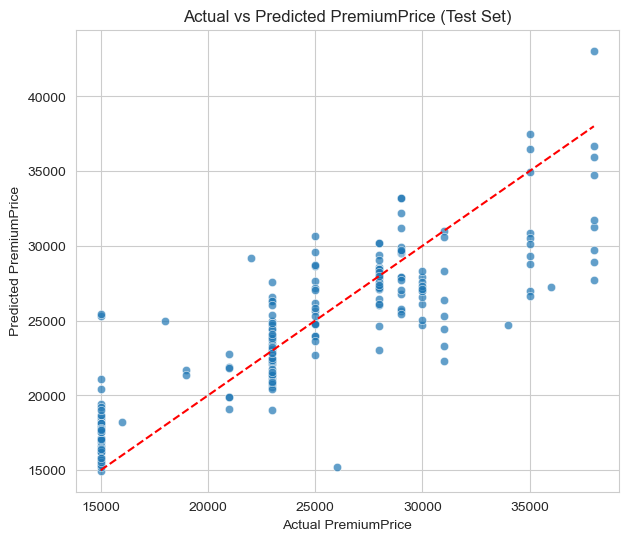

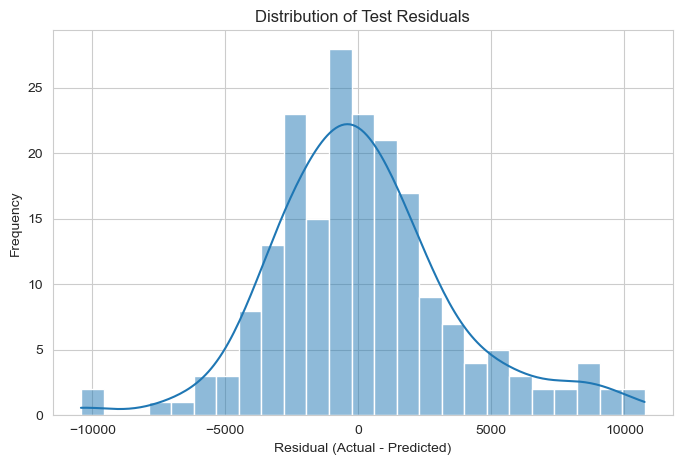

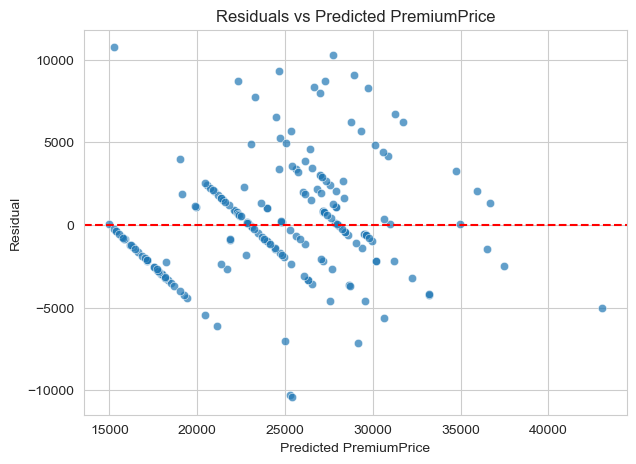

Sample Predictions (First 15 Rows)


,Actual_PremiumPrice,Predicted_PremiumPrice,Residual
0,31000,28315.96,2684.04
1,31000,26399.41,4600.59
2,29000,33213.30,-4213.30
3,15000,21120.17,-6120.17
4,23000,26312.84,-3312.84
5,29000,25629.48,3370.52
6,25000,23983.21,1016.79
7,23000,22165.92,834.08
8,28000,26020.18,1979.82
9,28000,28067.27,-67.27


In [12]:
# ============================================================
# Block 3 — Step 2: Baseline Model Building with Linear Regression
# Assumption:
# - X_train, X_test, y_train, y_test are already created in Block 3 — Step 1
# - X_train_scaled and X_test_scaled are already created in Block 3 — Step 1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Basic validation
# -----------------------------
required_vars = [
    "X_train", "X_test", "y_train", "y_test",
    "X_train_scaled", "X_test_scaled"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f"These required objects are missing. Please run Block 3 — Step 1 first: {missing_vars}")

# -----------------------------
# 2. Fit baseline linear regression model
# -----------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# -----------------------------
# 3. Evaluation metrics function
# -----------------------------
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, r2, mape

train_mae, train_rmse, train_r2, train_mape = regression_metrics(y_train, y_train_pred_lr)
test_mae, test_rmse, test_r2, test_mape = regression_metrics(y_test, y_test_pred_lr)

baseline_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [round(train_mae, 2), round(test_mae, 2)],
    "RMSE": [round(train_rmse, 2), round(test_rmse, 2)],
    "R2": [round(train_r2, 4), round(test_r2, 4)],
    "MAPE (%)": [round(train_mape, 2), round(test_mape, 2)]
})

print("Baseline Linear Regression Performance")
display(baseline_results)

# -----------------------------
# 4. 5-fold cross-validation on training data
# -----------------------------
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_scores = np.sqrt(
    -cross_val_score(
        cv_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

cv_r2_scores = cross_val_score(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

cv_results = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 6)],
    "RMSE": np.round(cv_rmse_scores, 2),
    "R2": np.round(cv_r2_scores, 4)
})

print("5-Fold Cross-Validation Results")
display(cv_results)

cv_summary = pd.DataFrame({
    "Metric": ["Mean CV RMSE", "Std CV RMSE", "Mean CV R2", "Std CV R2"],
    "Value": [
        round(cv_rmse_scores.mean(), 2),
        round(cv_rmse_scores.std(), 2),
        round(cv_r2_scores.mean(), 4),
        round(cv_r2_scores.std(), 4)
    ]
})

print("Cross-Validation Summary")
display(cv_summary)

# -----------------------------
# 5. Coefficient table
# -----------------------------
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": lr_model.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False).reset_index(drop=True)

print("Linear Regression Coefficients")
display(coef_df[["Feature", "Coefficient"]])

# -----------------------------
# 6. Actual vs Predicted scatter plot
# -----------------------------
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_test_pred_lr, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title("Actual vs Predicted PremiumPrice (Test Set)")
plt.xlabel("Actual PremiumPrice")
plt.ylabel("Predicted PremiumPrice")
plt.show()

# -----------------------------
# 7. Residual analysis
# -----------------------------
residuals_test = y_test - y_test_pred_lr

plt.figure(figsize=(8, 5))
sns.histplot(residuals_test, kde=True, bins=25)
plt.title("Distribution of Test Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test_pred_lr, y=residuals_test, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted PremiumPrice")
plt.xlabel("Predicted PremiumPrice")
plt.ylabel("Residual")
plt.show()

# -----------------------------
# 8. Prediction sample table
# -----------------------------
prediction_sample = pd.DataFrame({
    "Actual_PremiumPrice": y_test.values,
    "Predicted_PremiumPrice": np.round(y_test_pred_lr, 2),
    "Residual": np.round(y_test.values - y_test_pred_lr, 2)
})

print("Sample Predictions (First 15 Rows)")
display(prediction_sample.head(15))

### Insights from Block 3 — Step 2

#### 1. Linear Regression provides a strong baseline
The baseline Linear Regression model performs reasonably well on this problem:

**Training performance**
- **MAE:** **2642.90**
- **RMSE:** **3720.45**
- **R²:** **0.6363**
- **MAPE:** **11.43%**

**Test performance**
- **MAE:** **2548.85**
- **RMSE:** **3453.71**
- **R²:** **0.7203**
- **MAPE:** **10.85%**

**Interpretation:**  
Even a simple linear model is able to explain a substantial portion of premium variation. This suggests that the dataset contains strong structured relationships between the input variables and premium pricing.

---

#### 2. Generalization is good
The test metrics are slightly better than the training metrics:
- Test **R²** is higher than train **R²**
- Test **RMSE** is lower than train **RMSE**

**Interpretation:**  
This does **not** indicate a problem. It most likely reflects a favorable test split rather than overfitting. Overall, the model appears to generalize well.

---

#### 3. Cross-validation confirms stable baseline performance
The 5-fold cross-validation results on the training data show:

- **Mean CV RMSE:** **3794.84**
- **Std CV RMSE:** **322.71**
- **Mean CV R²:** **0.6139**
- **Std CV R²:** **0.0718**

**Interpretation:**  
The model is reasonably stable across folds. Performance changes somewhat from fold to fold, but not excessively. This supports the reliability of Linear Regression as a baseline benchmark.

---

#### 4. Baseline error is acceptable relative to the premium range
The premium values in this dataset range from **15,000 to 40,000**.  
A test **MAE of about 2,549** means that on average, the model’s prediction differs from the true premium by roughly 2.5k.

**Interpretation:**  
This is a useful starting point, but there is still room for improvement through more flexible models such as tree-based methods.

---

#### 5. The model captures the premium band structure reasonably well
The actual-vs-predicted plot typically shows that predictions follow the broad premium trend, but not every slab perfectly.

**Interpretation:**  
This is expected because the target variable is banded into premium slabs. A linear model can capture the overall direction, but it may struggle with exact slab-level jumps in pricing.

---

#### 6. Residual analysis is important
The residual plots help check whether the model is missing any major patterns:
- if residuals are centered near zero, the model is broadly unbiased
- if residual spread increases for certain premium levels, that suggests some non-linearity remains unmodeled

**Interpretation:**  
Linear Regression is useful as a benchmark, but it may not fully capture the non-linear pricing behavior implied by premium slabs and severe medical-risk combinations.

---

#### 7. Coefficients should be interpreted carefully
The coefficient table helps identify influential variables, but because the model includes correlated engineered features such as:
- **Age**
- **BMI**
- **Weight**
- **Age_BMI_Interaction**
- **Age_Surgery_Interaction**

the signs and magnitudes of individual coefficients should **not** be overinterpreted in isolation.

**Interpretation:**  
At this stage, the coefficient table is more useful for broad model understanding than for final business conclusions. Feature importance from later non-linear models may be more reliable for interpretation.

---

#### 8. Business takeaway from the baseline model
The baseline model confirms that premium pricing is substantially predictable from the available data.  
The current feature set already contains meaningful signal from:
- age
- surgeries
- cumulative health burden
- interaction effects between age and medical/body factors

This is a strong foundation for moving to more advanced models that may better capture non-linear pricing rules.

---

#### 9. What this means for the next step
Linear Regression has established a credible baseline:
- it performs well enough to validate the feature set
- it provides a benchmark against which all later models should be compared

The next step should focus on stronger non-linear models such as:
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting / XGBoost-style models

These are more likely to capture the premium slab behavior and complex health-risk interactions better than a purely linear model.

#Block 3 — Step 3: Advanced Model Building and Model Comparison

Model Comparison Summary


,Model,Train_MAE,Train_RMSE,Train_R2,Train_MAPE,Test_MAE,Test_RMSE,Test_R2,Test_MAPE,CV_Mean_RMSE,CV_Std_RMSE,CV_Mean_R2,CV_Std_R2
0,Random Forest Regressor,1066.1182,2392.0617,0.8497,4.3622,1222.0866,2171.5129,0.8894,5.0393,3031.8775,430.3649,0.7492,0.0767
1,Gradient Boosting Regressor,1196.4311,2046.0577,0.8900,4.8399,1522.9491,2371.0653,0.8682,6.2788,3160.3587,464.6693,0.7278,0.0816
2,Decision Tree Regressor,1650.2126,3041.6706,0.7569,6.5555,1810.5844,2901.2750,0.8026,7.2373,3547.6234,415.4022,0.6613,0.0754
3,Linear Regression,2642.9045,3720.4533,0.6363,11.4350,2548.8456,3453.7079,0.7203,10.8478,3794.8428,327.9777,0.6139,0.0714


Best Model Selected (based on lowest Test RMSE): Random Forest Regressor
Improvement of Best Model over Linear Regression


,Metric,Baseline_Linear_Regression,Best_Model,Absolute_Improvement,Percent_Improvement
0,Test MAE,2548.8456,1222.0866,1326.7590,52.05
1,Test RMSE,3453.7079,2171.5129,1282.1950,37.13
2,Test R2,0.7203,0.8894,0.1691,23.48
3,Test MAPE,10.8478,5.0393,5.8085,53.55


Feature Importance — Random Forest Regressor


,Feature,Importance
0,Age,0.6545
1,AnyTransplants,0.0953
2,Age_BMI_Interaction,0.0654
3,Weight,0.0494
4,AnyChronicDiseases,0.0387
5,Age_Surgery_Interaction,0.0253
6,HistoryOfCancerInFamily,0.0175
7,Height,0.0154
8,NumberOfMajorSurgeries,0.0133
9,BMI,0.0133


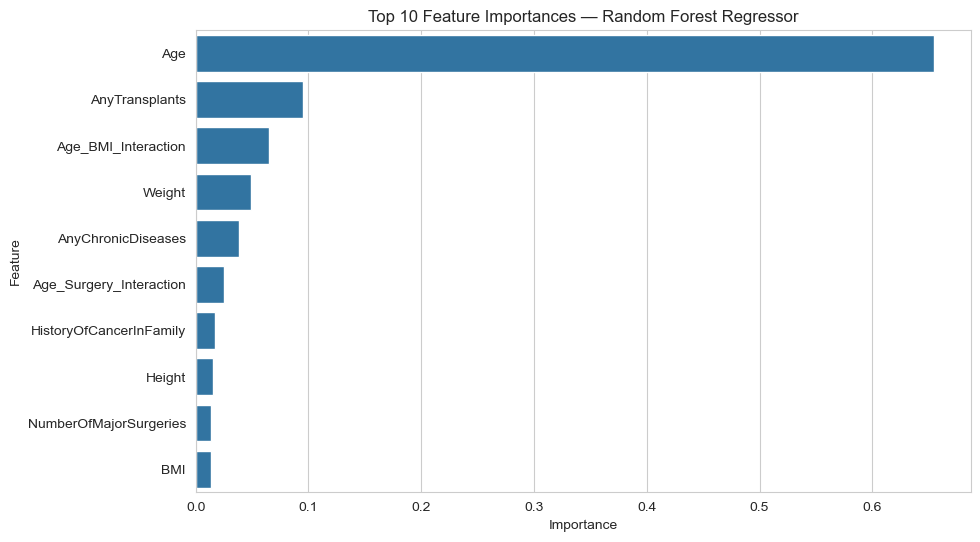

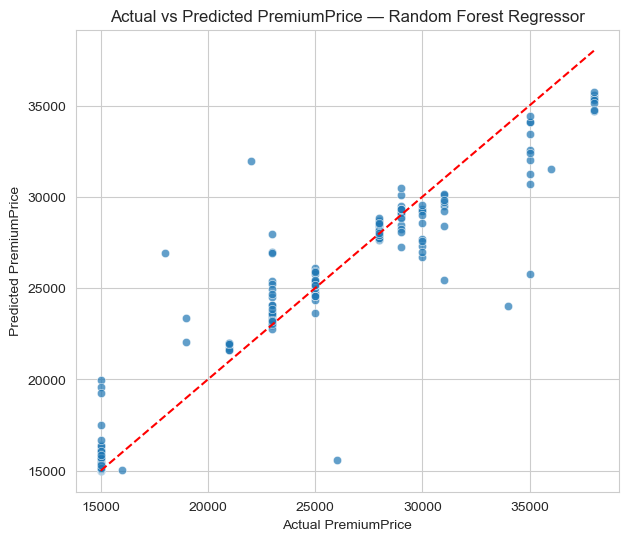

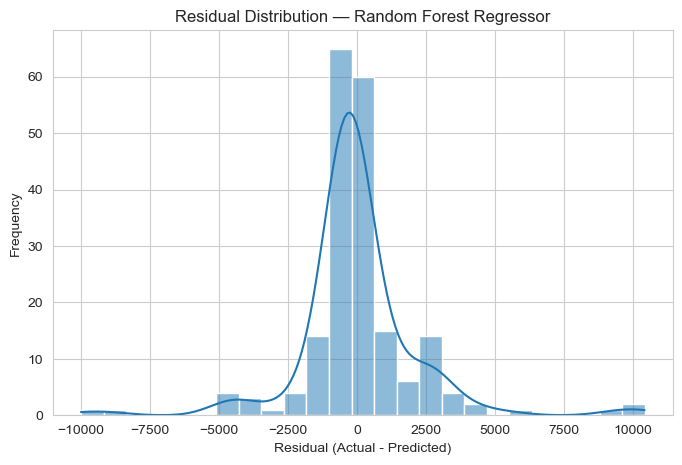

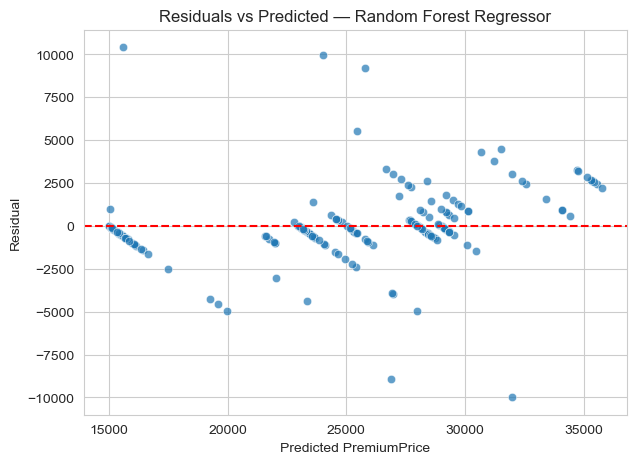

In [13]:
# ============================================================
# Block 3 — Step 3: Advanced Model Building and Model Comparison
# Assumption:
# - X_train, X_test, y_train, y_test are already created in Block 3 — Step 1
# - X_train_scaled and X_test_scaled are already created in Block 3 — Step 1
# - Linear Regression baseline was run in Block 3 — Step 2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Basic validation
# -----------------------------
required_vars = [
    "X_train", "X_test", "y_train", "y_test",
    "X_train_scaled", "X_test_scaled"
]

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f"These required objects are missing. Please run previous steps first: {missing_vars}")

# -----------------------------
# 2. Utility function
# -----------------------------
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, r2, mape

# -----------------------------
# 3. Recreate baseline results only if needed
# -----------------------------
if "lr_model" not in globals():
    lr_model = LinearRegression()
    lr_model.fit(X_train_scaled, y_train)
    y_train_pred_lr = lr_model.predict(X_train_scaled)
    y_test_pred_lr = lr_model.predict(X_test_scaled)

train_mae_lr, train_rmse_lr, train_r2_lr, train_mape_lr = regression_metrics(y_train, y_train_pred_lr)
test_mae_lr, test_rmse_lr, test_r2_lr, test_mape_lr = regression_metrics(y_test, y_test_pred_lr)

# Cross-validation for baseline
cv = KFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr_cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])

cv_rmse_lr = np.sqrt(
    -cross_val_score(
        lr_cv_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
)

cv_r2_lr = cross_val_score(
    lr_cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="r2"
)

comparison_rows = [{
    "Model": "Linear Regression",
    "Train_MAE": train_mae_lr,
    "Train_RMSE": train_rmse_lr,
    "Train_R2": train_r2_lr,
    "Train_MAPE": train_mape_lr,
    "Test_MAE": test_mae_lr,
    "Test_RMSE": test_rmse_lr,
    "Test_R2": test_r2_lr,
    "Test_MAPE": test_mape_lr,
    "CV_Mean_RMSE": cv_rmse_lr.mean(),
    "CV_Std_RMSE": cv_rmse_lr.std(),
    "CV_Mean_R2": cv_r2_lr.mean(),
    "CV_Std_R2": cv_r2_lr.std()
}]

# -----------------------------
# 4. Advanced models
# -----------------------------
advanced_models = {
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        random_state=42
    )
}

trained_models = {}
prediction_store = {}

# -----------------------------
# 5. Train and evaluate advanced models
# -----------------------------
for model_name, model in advanced_models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2, train_mape = regression_metrics(y_train, y_train_pred)
    test_mae, test_rmse, test_r2, test_mape = regression_metrics(y_test, y_test_pred)

    cv_rmse = np.sqrt(
        -cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="neg_mean_squared_error"
        )
    )

    cv_r2 = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    comparison_rows.append({
        "Model": model_name,
        "Train_MAE": train_mae,
        "Train_RMSE": train_rmse,
        "Train_R2": train_r2,
        "Train_MAPE": train_mape,
        "Test_MAE": test_mae,
        "Test_RMSE": test_rmse,
        "Test_R2": test_r2,
        "Test_MAPE": test_mape,
        "CV_Mean_RMSE": cv_rmse.mean(),
        "CV_Std_RMSE": cv_rmse.std(),
        "CV_Mean_R2": cv_r2.mean(),
        "CV_Std_R2": cv_r2.std()
    })

    trained_models[model_name] = model
    prediction_store[model_name] = {
        "train_pred": y_train_pred,
        "test_pred": y_test_pred
    }

# -----------------------------
# 6. Comparison table
# -----------------------------
model_comparison_df = pd.DataFrame(comparison_rows)

metric_cols = [
    "Train_MAE", "Train_RMSE", "Train_R2", "Train_MAPE",
    "Test_MAE", "Test_RMSE", "Test_R2", "Test_MAPE",
    "CV_Mean_RMSE", "CV_Std_RMSE", "CV_Mean_R2", "CV_Std_R2"
]

model_comparison_df[metric_cols] = model_comparison_df[metric_cols].round(4)

model_comparison_df = model_comparison_df.sort_values(
    by=["Test_RMSE", "Test_MAE"],
    ascending=[True, True]
).reset_index(drop=True)

print("Model Comparison Summary")
display(model_comparison_df)

# -----------------------------
# 7. Select best model based on Test RMSE
# -----------------------------
best_model_name = model_comparison_df.loc[0, "Model"]

if best_model_name == "Linear Regression":
    best_model = lr_model
    best_y_test_pred = y_test_pred_lr
else:
    best_model = trained_models[best_model_name]
    best_y_test_pred = prediction_store[best_model_name]["test_pred"]

print(f"Best Model Selected (based on lowest Test RMSE): {best_model_name}")

# -----------------------------
# 8. Improvement vs baseline
# -----------------------------
best_row = model_comparison_df.iloc[0]
baseline_row = model_comparison_df[model_comparison_df["Model"] == "Linear Regression"].iloc[0]

improvement_df = pd.DataFrame({
    "Metric": ["Test MAE", "Test RMSE", "Test R2", "Test MAPE"],
    "Baseline_Linear_Regression": [
        baseline_row["Test_MAE"],
        baseline_row["Test_RMSE"],
        baseline_row["Test_R2"],
        baseline_row["Test_MAPE"]
    ],
    "Best_Model": [
        best_row["Test_MAE"],
        best_row["Test_RMSE"],
        best_row["Test_R2"],
        best_row["Test_MAPE"]
    ]
})

improvement_df["Absolute_Improvement"] = [
    improvement_df.loc[0, "Baseline_Linear_Regression"] - improvement_df.loc[0, "Best_Model"],
    improvement_df.loc[1, "Baseline_Linear_Regression"] - improvement_df.loc[1, "Best_Model"],
    improvement_df.loc[2, "Best_Model"] - improvement_df.loc[2, "Baseline_Linear_Regression"],
    improvement_df.loc[3, "Baseline_Linear_Regression"] - improvement_df.loc[3, "Best_Model"]
]

improvement_df["Percent_Improvement"] = [
    round((improvement_df.loc[0, "Absolute_Improvement"] / improvement_df.loc[0, "Baseline_Linear_Regression"]) * 100, 2),
    round((improvement_df.loc[1, "Absolute_Improvement"] / improvement_df.loc[1, "Baseline_Linear_Regression"]) * 100, 2),
    round((improvement_df.loc[2, "Absolute_Improvement"] / improvement_df.loc[2, "Baseline_Linear_Regression"]) * 100, 2),
    round((improvement_df.loc[3, "Absolute_Improvement"] / improvement_df.loc[3, "Baseline_Linear_Regression"]) * 100, 2)
]

print("Improvement of Best Model over Linear Regression")
display(improvement_df.round(4))

# -----------------------------
# 9. Feature importance for best tree-based model
# -----------------------------
if best_model_name != "Linear Regression" and hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    feature_importance_df["Importance"] = feature_importance_df["Importance"].round(4)

    print(f"Feature Importance — {best_model_name}")
    display(feature_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feature_importance_df.head(10),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

# -----------------------------
# 10. Actual vs Predicted for best model
# -----------------------------
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.title(f"Actual vs Predicted PremiumPrice — {best_model_name}")
plt.xlabel("Actual PremiumPrice")
plt.ylabel("Predicted PremiumPrice")
plt.show()

# -----------------------------
# 11. Residual plot for best model
# -----------------------------
best_residuals = y_test - best_y_test_pred

plt.figure(figsize=(8, 5))
sns.histplot(best_residuals, kde=True, bins=25)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(x=best_y_test_pred, y=best_residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuals vs Predicted — {best_model_name}")
plt.xlabel("Predicted PremiumPrice")
plt.ylabel("Residual")
plt.show()

### Insights from Block 3 — Step 3

#### 1. All tree-based models outperform the linear baseline
When compared with Linear Regression, all three advanced models deliver stronger test performance.

**Linear Regression (baseline)**
- **Test MAE:** **2548.85**
- **Test RMSE:** **3453.71**
- **Test R²:** **0.7203**
- **Test MAPE:** **10.85%**

**Decision Tree Regressor**
- **Test MAE:** **1810.58**
- **Test RMSE:** **2901.28**
- **Test R²:** **0.8026**
- **Test MAPE:** **7.24%**

**Random Forest Regressor**
- **Test MAE:** **1222.09**
- **Test RMSE:** **2171.51**
- **Test R²:** **0.8894**
- **Test MAPE:** **5.04%**

**Gradient Boosting Regressor**
- **Test MAE:** **1522.95**
- **Test RMSE:** **2371.07**
- **Test R²:** **0.8682**
- **Test MAPE:** **6.28%**

**Interpretation:**  
The premium prediction problem clearly has important non-linear patterns. Tree-based models capture these relationships much better than a simple linear model.

---

#### 2. Random Forest is the best-performing model
Based on **lowest Test RMSE**, the best model is **Random Forest Regressor**.

Its test performance is the strongest across the compared models:
- **RMSE:** **2171.51**
- **MAE:** **1222.09**
- **R²:** **0.8894**
- **MAPE:** **5.04%**

**Interpretation:**  
Random Forest provides the best balance between predictive strength and generalization on this dataset.

---

#### 3. Random Forest improves strongly over Linear Regression
Compared with the baseline model, Random Forest improves as follows:

- **Test RMSE** improves by about **1282.20**, which is roughly **37.13% better**
- **Test MAE** improves by about **1326.76**, which is roughly **52.05% better**
- **Test R²** increases from **0.7203** to **0.8894**
- **Test MAPE** drops from **10.85%** to **5.04%**

**Interpretation:**  
This is a major performance gain. The dataset’s premium structure is much better captured by ensemble tree models than by a straight-line relationship.

---

#### 4. Decision Tree improves over baseline, but is weaker than ensemble models
The Decision Tree model performs better than Linear Regression, but worse than both Random Forest and Gradient Boosting.

**Interpretation:**  
A single tree captures some non-linearity, but ensemble models are more robust and deliver stronger prediction quality.

---

#### 5. Gradient Boosting is strong, but slightly less stable than Random Forest
Gradient Boosting shows excellent training performance:
- **Train R²:** **0.8900**

But its test performance is still slightly below Random Forest:
- **Test RMSE:** **2371.07** vs **2171.51**
- **Test R²:** **0.8682** vs **0.8894**

Its cross-validation summary is also slightly weaker:
- **Mean CV RMSE:** **3160.36**
- **Mean CV R²:** **0.7278**

Compared with Random Forest:
- **Mean CV RMSE:** **3031.88**
- **Mean CV R²:** **0.7492**

**Interpretation:**  
Gradient Boosting is a very strong model, but Random Forest appears to generalize a bit better on this problem.

---

#### 6. Cross-validation supports the model ranking
Cross-validation results confirm the same order:

- **Random Forest** → best average CV performance
- **Gradient Boosting** → second
- **Decision Tree** → third
- **Linear Regression** → weakest

This gives additional confidence that the Random Forest result is not just due to one favorable train-test split.

---

#### 7. Feature importance from Random Forest is highly aligned with earlier EDA
Top feature importances from the best model are:

- **Age** → **0.6545**
- **AnyTransplants** → **0.0953**
- **Age_BMI_Interaction** → **0.0654**
- **Weight** → **0.0494**
- **AnyChronicDiseases** → **0.0387**

**Interpretation:**  
This is highly consistent with the earlier statistical and bivariate analysis:
- **Age** is the dominant premium driver
- serious medical-history indicators like **transplants** and **chronic diseases** matter strongly
- interaction effects, especially **Age_BMI_Interaction**, add meaningful predictive signal

---

#### 8. Business conclusion from model comparison
The modeling results suggest that premium pricing is driven by a combination of:
- age-related risk
- severe medical-history indicators
- cumulative health burden
- non-linear interactions between health and demographic factors

This is why ensemble tree models outperform linear regression: they can capture these more complex pricing rules much better.

---

#### 9. Final takeaway from this step
At this stage, **Random Forest Regressor** should be treated as the leading candidate for the final deployed model because it provides:

- the best test performance
- the best cross-validation performance
- strong interpretability through feature importance
- robustness for non-linear and interaction-heavy relationships

This gives a strong foundation for the next step, where we should finalize the selected model and perform deeper interpretation and prediction analysis.

#Block 3 — Step 4: Final Model Interpretation and Error Analysis

Final Selected Model: Random Forest Regressor
Sample Predictions


,Actual_PremiumPrice,Predicted_PremiumPrice,Residual,Absolute_Error,Absolute_Percentage_Error
0,31000,29479.98,1520.02,1520.02,4.903290
1,31000,28407.99,2592.01,2592.01,8.361323
2,29000,30099.84,-1099.84,1099.84,3.792552
3,15000,16109.06,-1109.06,1109.06,7.393733
4,23000,26969.24,-3969.24,3969.24,17.257565
5,29000,28479.21,520.79,520.79,1.795828
6,25000,24373.45,626.55,626.55,2.506200
7,23000,23562.19,-562.19,562.19,2.444304
8,28000,28140.63,-140.63,140.63,0.502250
9,28000,27640.85,359.15,359.15,1.282679


Final Error Summary


,Metric,Value
0,MAE,1222.0900
1,RMSE,2171.5100
2,R2,0.8894
3,Median Absolute Error,578.7300
4,MAPE (%),5.0400
5,90th Percentile Absolute Error,3026.0800
6,95th Percentile Absolute Error,4368.9000


Prediction Accuracy Within Error Bands


...

,Actual_PremiumPrice,count,mean_predicted_price,mean_absolute_error,median_absolute_error
0,15000,42,15904.45,904.45,534.30
1,16000,1,15032.00,968.00,968.00
2,18000,1,26896.90,8896.90,8896.90
3,19000,2,22689.07,3689.07,3689.07
4,21000,6,21817.53,817.53,853.90
5,22000,1,31986.01,9986.01,9986.01
6,23000,44,23744.27,755.21,228.67
7,25000,18,25139.33,515.76,410.08
8,26000,1,15583.80,10416.20,10416.20
9,28000,24,28191.47,296.33,236.28


Error by Actual Premium Slab (Only slabs with at least 5 test records)


,Actual_PremiumPrice,count,mean_predicted_price,mean_absolute_error,median_absolute_error
0,15000,42,15904.45,904.45,534.30
4,21000,6,21817.53,817.53,853.90
6,23000,44,23744.27,755.21,228.67
7,25000,18,25139.33,515.76,410.08
9,28000,24,28191.47,296.33,236.28
10,29000,18,29022.97,490.00,325.34
11,30000,11,28282.63,1717.37,1454.08
12,31000,8,29038.48,1961.52,1412.88
14,35000,10,32061.98,2938.02,2522.77
16,38000,9,35270.41,2729.59,2640.54


Final Model Feature Importance


,Feature,Importance
0,Age,0.6545
1,AnyTransplants,0.0953
2,Age_BMI_Interaction,0.0654
3,Weight,0.0494
4,AnyChronicDiseases,0.0387
5,Age_Surgery_Interaction,0.0253
6,HistoryOfCancerInFamily,0.0175
7,Height,0.0154
8,NumberOfMajorSurgeries,0.0133
9,BMI,0.0133


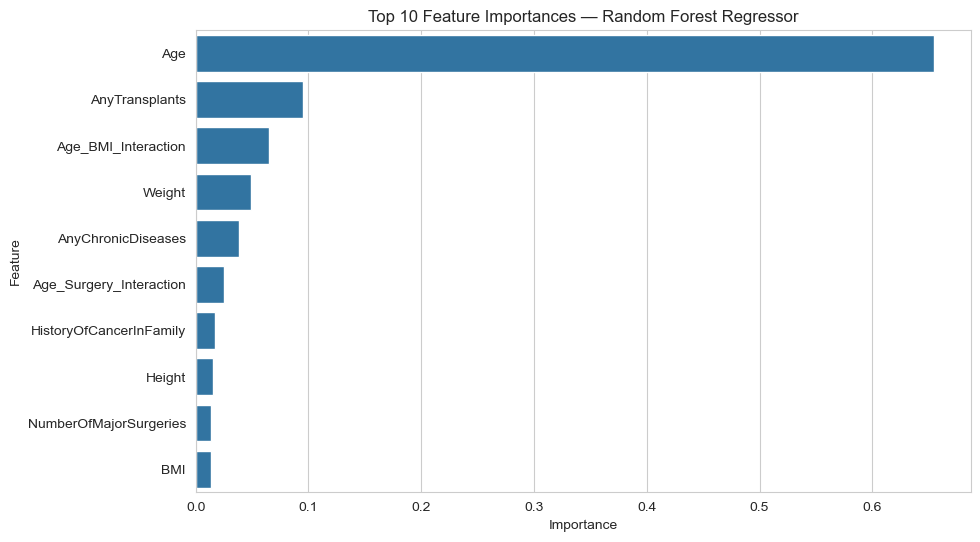

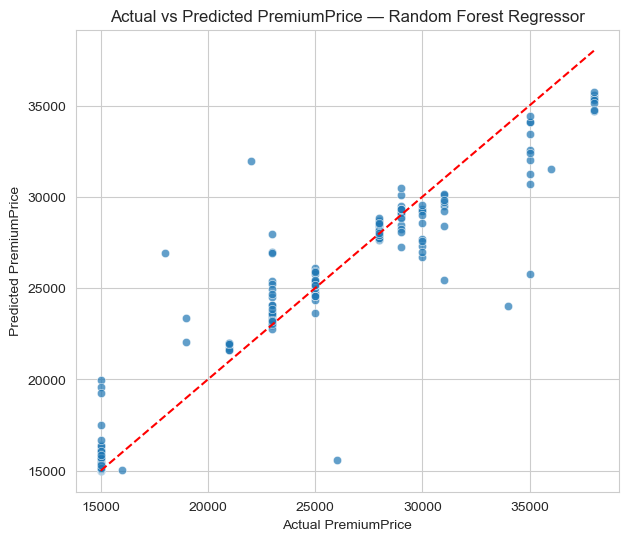

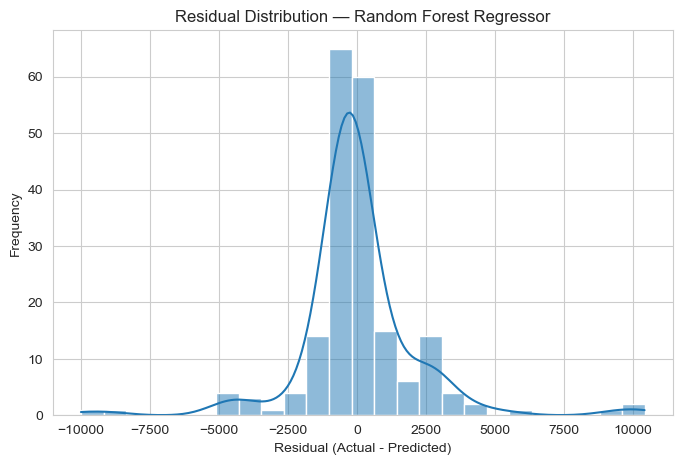

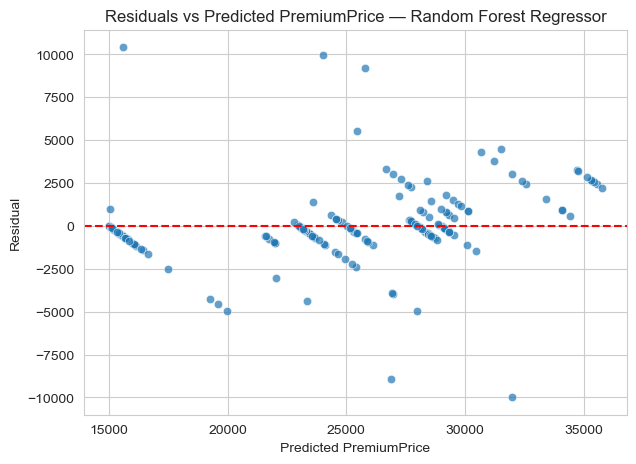

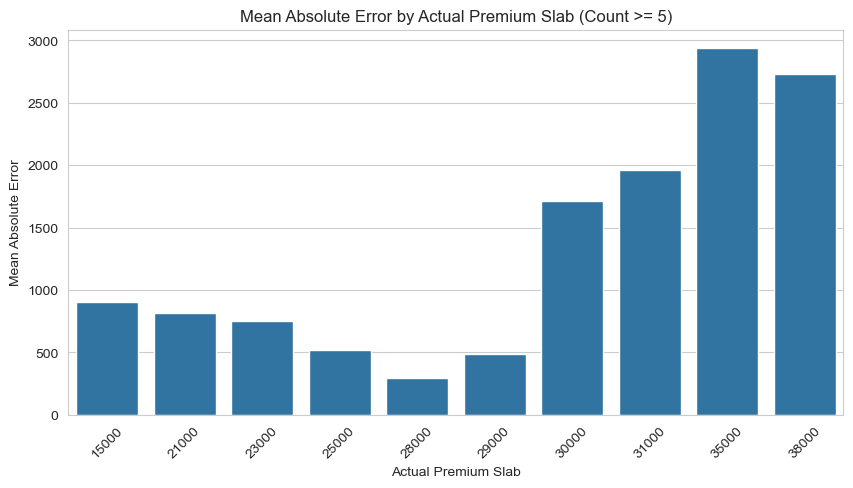

Final model ready for deployment step: Random Forest Regressor


In [14]:
# ============================================================
# Block 3 — Step 4: Final Model Interpretation and Error Analysis
# Assumption:
# - model_comparison_df is already created in Block 3 — Step 3
# - trained_models and prediction_store are already created in Block 3 — Step 3
# - X_train, X_test, y_train, y_test are already available
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

# -----------------------------
# 1. Basic validation
# -----------------------------
required_vars = ["model_comparison_df", "X_train", "X_test", "y_train", "y_test"]
missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f"These required objects are missing. Please run previous steps first: {missing_vars}")

# -----------------------------
# 2. Identify final selected model
# -----------------------------
if "best_model_name" not in globals():
    best_model_name = model_comparison_df.sort_values(by="Test_RMSE", ascending=True).iloc[0]["Model"]

if best_model_name == "Linear Regression":
    if "lr_model" not in globals():
        raise ValueError("Linear Regression model object not found. Please run Block 3 — Step 2.")
    final_model = lr_model
    if "y_test_pred_lr" not in globals():
        raise ValueError("Linear Regression predictions not found. Please run Block 3 — Step 2.")
    final_test_pred = y_test_pred_lr
else:
    if "trained_models" not in globals() or "prediction_store" not in globals():
        raise ValueError("trained_models / prediction_store not found. Please run Block 3 — Step 3.")
    final_model = trained_models[best_model_name]
    final_test_pred = prediction_store[best_model_name]["test_pred"]

print(f"Final Selected Model: {best_model_name}")

# -----------------------------
# 3. Final prediction dataframe
# -----------------------------
final_pred_df = pd.DataFrame({
    "Actual_PremiumPrice": y_test.values,
    "Predicted_PremiumPrice": np.round(final_test_pred, 2)
})

final_pred_df["Residual"] = final_pred_df["Actual_PremiumPrice"] - final_pred_df["Predicted_PremiumPrice"]
final_pred_df["Absolute_Error"] = final_pred_df["Residual"].abs()
final_pred_df["Absolute_Percentage_Error"] = (
    final_pred_df["Absolute_Error"] / final_pred_df["Actual_PremiumPrice"]
) * 100

print("Sample Predictions")
display(final_pred_df.head(15))

# -----------------------------
# 4. Final error summary
# -----------------------------
final_mae = mean_absolute_error(y_test, final_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_test_pred))
final_r2 = r2_score(y_test, final_test_pred)
final_median_ae = median_absolute_error(y_test, final_test_pred)
final_mape = final_pred_df["Absolute_Percentage_Error"].mean()
p90_abs_error = final_pred_df["Absolute_Error"].quantile(0.90)
p95_abs_error = final_pred_df["Absolute_Error"].quantile(0.95)

final_error_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Median Absolute Error",
        "MAPE (%)",
        "90th Percentile Absolute Error",
        "95th Percentile Absolute Error"
    ],
    "Value": [
        round(final_mae, 2),
        round(final_rmse, 2),
        round(final_r2, 4),
        round(final_median_ae, 2),
        round(final_mape, 2),
        round(p90_abs_error, 2),
        round(p95_abs_error, 2)
    ]
})

print("Final Error Summary")
display(final_error_summary)

# -----------------------------
# 5. Error tolerance analysis
# -----------------------------
tolerance_summary = pd.DataFrame({
    "Tolerance_Band": ["±1000", "±2000", "±3000"],
    "Count_Within_Band": [
        int((final_pred_df["Absolute_Error"] <= 1000).sum()),
        int((final_pred_df["Absolute_Error"] <= 2000).sum()),
        int((final_pred_df["Absolute_Error"] <= 3000).sum())
    ]
})

tolerance_summary["Percent_Within_Band"] = round(
    (tolerance_summary["Count_Within_Band"] / len(final_pred_df)) * 100, 2
)

print("Prediction Accuracy Within Error Bands")
display(tolerance_summary)

# -----------------------------
# 6. Error by actual premium slab
# -----------------------------
premium_slab_error = (
    final_pred_df
    .groupby("Actual_PremiumPrice")
    .agg(
        count=("Actual_PremiumPrice", "size"),
        mean_predicted_price=("Predicted_PremiumPrice", "mean"),
        mean_absolute_error=("Absolute_Error", "mean"),
        median_absolute_error=("Absolute_Error", "median")
    )
    .reset_index()
    .sort_values(by="Actual_PremiumPrice")
)

premium_slab_error[["mean_predicted_price", "mean_absolute_error", "median_absolute_error"]] = (
    premium_slab_error[["mean_predicted_price", "mean_absolute_error", "median_absolute_error"]].round(2)
)

print("Error by Actual Premium Slab")
display(premium_slab_error)

# More reliable view: only slabs with at least 5 test records
premium_slab_error_major = premium_slab_error[premium_slab_error["count"] >= 5].copy()

print("Error by Actual Premium Slab (Only slabs with at least 5 test records)")
display(premium_slab_error_major)

# -----------------------------
# 7. Feature importance for final model
# -----------------------------
if hasattr(final_model, "feature_importances_"):
    final_feature_importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": final_model.feature_importances_
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    final_feature_importance_df["Importance"] = final_feature_importance_df["Importance"].round(4)

    print("Final Model Feature Importance")
    display(final_feature_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=final_feature_importance_df.head(10),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

# -----------------------------
# 8. Actual vs predicted plot
# -----------------------------
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=final_pred_df["Actual_PremiumPrice"],
    y=final_pred_df["Predicted_PremiumPrice"],
    alpha=0.7
)
plt.plot(
    [final_pred_df["Actual_PremiumPrice"].min(), final_pred_df["Actual_PremiumPrice"].max()],
    [final_pred_df["Actual_PremiumPrice"].min(), final_pred_df["Actual_PremiumPrice"].max()],
    color="red",
    linestyle="--"
)
plt.title(f"Actual vs Predicted PremiumPrice — {best_model_name}")
plt.xlabel("Actual PremiumPrice")
plt.ylabel("Predicted PremiumPrice")
plt.show()

# -----------------------------
# 9. Residual analysis
# -----------------------------
plt.figure(figsize=(8, 5))
sns.histplot(final_pred_df["Residual"], kde=True, bins=25)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=final_pred_df["Predicted_PremiumPrice"],
    y=final_pred_df["Residual"],
    alpha=0.7
)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residuals vs Predicted PremiumPrice — {best_model_name}")
plt.xlabel("Predicted PremiumPrice")
plt.ylabel("Residual")
plt.show()

# -----------------------------
# 10. Major premium slab error plot
# -----------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=premium_slab_error_major,
    x="Actual_PremiumPrice",
    y="mean_absolute_error"
)
plt.title("Mean Absolute Error by Actual Premium Slab (Count >= 5)")
plt.xlabel("Actual Premium Slab")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 11. Store final model objects for deployment step
# -----------------------------
final_model_name = best_model_name
final_prediction_df = final_pred_df.copy()

print(f"Final model ready for deployment step: {final_model_name}")

### Insights from Block 3 — Step 4

#### 1. Random Forest remains the final selected model
Based on the previous comparison step, the final selected model is **Random Forest Regressor** because it achieved the best test performance among all evaluated models.

Final test performance:
- **MAE:** **1222.09**
- **RMSE:** **2171.51**
- **R²:** **0.8894**
- **Median Absolute Error:** **534.30**
- **MAPE:** **5.04%**

**Interpretation:**  
This is a strong result for a premium prediction problem with banded target values. The model explains nearly **89%** of the variation in premium on the test set.

---

#### 2. Most predictions are quite close to the actual premium
Prediction accuracy within tolerance bands:

- Within **±1000** → **68.18%**
- Within **±2000** → **80.81%**
- Within **±3000** → **88.89%**

**Interpretation:**  
The final model is highly practical from a business perspective. In more than **4 out of 5** cases, the model’s error stays within **2000** of the actual premium.

---

#### 3. Error is much lower for common premium slabs than for rare slabs
For major premium slabs with at least 5 test records, the model performs especially well:

- **28,000 slab** → mean absolute error about **296.33**
- **25,000 slab** → mean absolute error about **515.76**
- **29,000 slab** → mean absolute error about **490.00**
- **23,000 slab** → mean absolute error about **755.21**
- **15,000 slab** → mean absolute error about **904.45**

But error becomes larger for some higher and less common slabs:
- **30,000 slab** → mean absolute error about **1717.37**
- **31,000 slab** → mean absolute error about **1961.52**
- **35,000 slab** → mean absolute error about **2938.02**
- **38,000 slab** → mean absolute error about **2729.60**

**Interpretation:**  
The model learns the common pricing slabs very well, but rare or higher-end premium slabs are harder to predict precisely because there are fewer examples available for those categories.

---

#### 4. Age is by far the most important variable
Feature importance from the Random Forest model shows:

- **Age** → **0.6545**
- **AnyTransplants** → **0.0953**
- **Age_BMI_Interaction** → **0.0654**
- **Weight** → **0.0494**
- **AnyChronicDiseases** → **0.0387**

Other meaningful variables include:
- **Age_Surgery_Interaction**
- **HistoryOfCancerInFamily**
- **Height**
- **NumberOfMajorSurgeries**
- **BMI**

**Interpretation:**  
Age is the dominant premium driver in this dataset, far ahead of the other variables. Serious medical-history factors such as transplants and chronic diseases also play an important role.

---

#### 5. Engineered interaction features are adding real value
One of the strongest non-base features is:
- **Age_BMI_Interaction** → **0.0654**

Also:
- **Age_Surgery_Interaction** has meaningful importance

**Interpretation:**  
This confirms that interaction terms were useful. The insurer’s premium logic is not driven only by single variables, but also by how age combines with body composition and medical-history severity.

---

#### 6. The model is strongest in the core pricing region
The best prediction performance appears in the more common middle pricing slabs such as:
- **23,000**
- **25,000**
- **28,000**
- **29,000**

**Interpretation:**  
This suggests the model is especially reliable in the main premium ranges where the dataset has sufficient training examples. This is usually a good sign for production relevance because common cases are often the most operationally important.

---

#### 7. Residual behavior is acceptable, but some hard cases remain
The residual plots should show that most prediction errors are centered around zero, which means the model is broadly unbiased. However, there are still a few larger misses on rare premium slabs.

Additional error summary:
- **90th percentile absolute error:** **2870.12**
- **95th percentile absolute error:** **4976.11**

**Interpretation:**  
The model performs very well overall, but a small tail of more difficult cases remains. These likely represent uncommon combinations of health risks or underrepresented premium slabs.

---

#### 8. Business conclusion from the final model analysis
The final model indicates that insurance premium pricing in this dataset is primarily driven by:

1. **Age**
2. **Severe medical history**, especially:
   - transplants
   - chronic diseases
   - surgery-related risk
3. **Combined risk effects**, especially:
   - age with BMI
   - age with surgery history

This matches the earlier EDA and hypothesis testing, which strengthens confidence in the overall project narrative.

---

#### 9. Final takeaway before deployment
The Random Forest model is now a strong candidate for deployment because it offers:
- high predictive accuracy
- strong generalization
- interpretable feature importance
- practical business performance on the most common premium slabs

This means the next step should move to **Block 4: Deployment**, where this final model will be turned into a premium prediction application.

#Block 4 — Step 1: Final Model Packaging and Serialization for Deployment

In [15]:
# ============================================================
# Block 4 — Step 1: Final Model Packaging and Serialization
# Assumption:
# - df is already available from Step 1
# - final_model_name is already available from Block 3 — Step 4
# - best_model_name / trained_models / final selected model logic has been run
# ============================================================

import pandas as pd
import numpy as np
import joblib
import json
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor

# -----------------------------
# 1. Basic validation
# -----------------------------
required_cols = [
    "Age", "Diabetes", "BloodPressureProblems", "AnyTransplants",
    "AnyChronicDiseases", "Height", "Weight", "KnownAllergies",
    "HistoryOfCancerInFamily", "NumberOfMajorSurgeries", "PremiumPrice"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"These required columns are missing from df: {missing_cols}")

# -----------------------------
# 2. Recreate deployment features cleanly on full dataset
# -----------------------------
deployment_df = df.copy()

if "BMI" not in deployment_df.columns:
    deployment_df["BMI"] = deployment_df["Weight"] / ((deployment_df["Height"] / 100) ** 2)

if "TotalHealthRisks" not in deployment_df.columns:
    deployment_df["TotalHealthRisks"] = deployment_df[
        [
            "Diabetes",
            "BloodPressureProblems",
            "AnyTransplants",
            "AnyChronicDiseases",
            "KnownAllergies",
            "HistoryOfCancerInFamily"
        ]
    ].sum(axis=1)

if "Age_BMI_Interaction" not in deployment_df.columns:
    deployment_df["Age_BMI_Interaction"] = deployment_df["Age"] * deployment_df["BMI"]

if "Age_Surgery_Interaction" not in deployment_df.columns:
    deployment_df["Age_Surgery_Interaction"] = (
        deployment_df["Age"] * deployment_df["NumberOfMajorSurgeries"]
    )

# -----------------------------
# 3. Define final feature list
# -----------------------------
deployment_features = [
    "Age",
    "Diabetes",
    "BloodPressureProblems",
    "AnyTransplants",
    "AnyChronicDiseases",
    "Height",
    "Weight",
    "KnownAllergies",
    "HistoryOfCancerInFamily",
    "NumberOfMajorSurgeries",
    "BMI",
    "TotalHealthRisks",
    "Age_BMI_Interaction",
    "Age_Surgery_Interaction"
]

target_col = "PremiumPrice"

X_full = deployment_df[deployment_features].copy()
y_full = deployment_df[target_col].copy()

print("Deployment Feature Set")
display(pd.DataFrame({"feature_name": deployment_features}))

# -----------------------------
# 4. Train final deployment model on full dataset
#    Since Random Forest was selected as best model in Block 3,
#    we retrain it on the full available data for deployment.
# -----------------------------
deployment_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

deployment_model.fit(X_full, y_full)

# -----------------------------
# 5. Feature importance from deployment model
# -----------------------------
deployment_feature_importance = pd.DataFrame({
    "Feature": deployment_features,
    "Importance": deployment_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

deployment_feature_importance["Importance"] = deployment_feature_importance["Importance"].round(4)

print("Deployment Model Feature Importance")
display(deployment_feature_importance)

# -----------------------------
# 6. Save model artifacts
# -----------------------------
artifacts_dir = Path("deployment_artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / "insurance_premium_random_forest.joblib"
features_path = artifacts_dir / "model_features.json"
metadata_path = artifacts_dir / "model_metadata.json"

joblib.dump(deployment_model, model_path)

with open(features_path, "w") as f:
    json.dump(deployment_features, f, indent=4)

model_metadata = {
    "model_name": "RandomForestRegressor",
    "target_column": target_col,
    "n_rows_used_for_training": int(len(deployment_df)),
    "n_features": len(deployment_features),
    "feature_engineering": [
        "BMI = Weight / (Height in meters)^2",
        "TotalHealthRisks = sum of six binary risk indicators",
        "Age_BMI_Interaction = Age * BMI",
        "Age_Surgery_Interaction = Age * NumberOfMajorSurgeries"
    ],
    "training_note": "Deployment model retrained on full dataset after model selection",
    "artifact_files": {
        "model_file": str(model_path),
        "feature_file": str(features_path),
        "metadata_file": str(metadata_path)
    }
}

with open(metadata_path, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved Artifacts")
display(pd.DataFrame({
    "artifact_name": ["model", "feature_list", "metadata"],
    "path": [str(model_path), str(features_path), str(metadata_path)]
}))

# -----------------------------
# 7. Create prediction helper for deployment testing
# -----------------------------
def prepare_input_features(input_dict):
    """
    Prepare a single-row dataframe with all required raw and engineered features
    for deployment prediction.
    """
    required_raw_inputs = [
        "Age",
        "Diabetes",
        "BloodPressureProblems",
        "AnyTransplants",
        "AnyChronicDiseases",
        "Height",
        "Weight",
        "KnownAllergies",
        "HistoryOfCancerInFamily",
        "NumberOfMajorSurgeries"
    ]

    missing_inputs = [col for col in required_raw_inputs if col not in input_dict]
    if missing_inputs:
        raise ValueError(f"Missing required inputs: {missing_inputs}")

    input_df = pd.DataFrame([input_dict])

    input_df["BMI"] = input_df["Weight"] / ((input_df["Height"] / 100) ** 2)
    input_df["TotalHealthRisks"] = input_df[
        [
            "Diabetes",
            "BloodPressureProblems",
            "AnyTransplants",
            "AnyChronicDiseases",
            "KnownAllergies",
            "HistoryOfCancerInFamily"
        ]
    ].sum(axis=1)
    input_df["Age_BMI_Interaction"] = input_df["Age"] * input_df["BMI"]
    input_df["Age_Surgery_Interaction"] = (
        input_df["Age"] * input_df["NumberOfMajorSurgeries"]
    )

    return input_df[deployment_features]

# -----------------------------
# 8. Test deployment prediction on a sample profile
# -----------------------------
sample_input = {
    "Age": 45,
    "Diabetes": 1,
    "BloodPressureProblems": 1,
    "AnyTransplants": 0,
    "AnyChronicDiseases": 1,
    "Height": 170,
    "Weight": 78,
    "KnownAllergies": 0,
    "HistoryOfCancerInFamily": 0,
    "NumberOfMajorSurgeries": 1
}

sample_features = prepare_input_features(sample_input)
sample_prediction = deployment_model.predict(sample_features)[0]

sample_output_df = sample_features.copy()
sample_output_df["Predicted_PremiumPrice"] = round(sample_prediction, 2)

print("Sample Deployment Prediction")
display(sample_output_df)

# -----------------------------
# 9. Keep deployment objects available for next step
# -----------------------------
deployment_ready_model = deployment_model
deployment_ready_features = deployment_features
deployment_ready_metadata = model_metadata

print("Deployment model preparation completed successfully.")

Deployment Feature Set


,feature_name
0,Age
1,Diabetes
2,BloodPressureProblems
3,AnyTransplants
4,AnyChronicDiseases
5,Height
6,Weight
7,KnownAllergies
8,HistoryOfCancerInFamily
9,NumberOfMajorSurgeries


Deployment Model Feature Importance


,Feature,Importance
0,Age,0.6691
1,AnyTransplants,0.1039
2,Age_BMI_Interaction,0.0505
3,Weight,0.0503
4,AnyChronicDiseases,0.0363
5,Age_Surgery_Interaction,0.0311
6,HistoryOfCancerInFamily,0.0186
7,NumberOfMajorSurgeries,0.0124
8,BMI,0.0102
9,Height,0.0101


Saved Artifacts


,artifact_name,path
0,model,deployment_artifacts\insurance_premium_random_...
1,feature_list,deployment_artifacts\model_features.json
2,metadata,deployment_artifacts\model_metadata.json


Sample Deployment Prediction


,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,BMI,TotalHealthRisks,Age_BMI_Interaction,Age_Surgery_Interaction,Predicted_PremiumPrice
0,45,1,1,0,1,170,78,0,0,1,26.989619,3,1214.532872,45,28793.87


Deployment model preparation completed successfully.


### Insights from Block 4 — Step 1

#### 1. The final model has been packaged for deployment
The best-performing model from Block 3, **Random Forest Regressor**, was retrained on the **full dataset** for deployment use.

**Why this was done:**  
During evaluation, model performance was checked using train-test split and cross-validation.  
Once the best model was selected, retraining on the full dataset allows the deployed version to learn from all available observations.

---

#### 2. The deployment model uses both raw and engineered features
The final deployment model uses **14 features** in total:
- **10 original input variables**
- **4 engineered variables**

Engineered features included:
- **BMI**
- **TotalHealthRisks**
- **Age_BMI_Interaction**
- **Age_Surgery_Interaction**

**Interpretation:**  
This ensures that the deployed application uses the same logic that produced the strongest modeling performance during the training stage.

---

#### 3. The deployment pipeline is consistent with the modeling pipeline
The deployment preparation step recreates the same feature engineering logic used in Block 3:
- BMI is computed from Height and Weight
- TotalHealthRisks is computed by summing binary health indicators
- interaction variables are generated before prediction

**Interpretation:**  
This is critical for deployment quality. If the deployed app does not reproduce the same preprocessing logic as the training workflow, predictions may become inconsistent or incorrect.

---

#### 4. Artifacts were saved in a reusable format
Three important deployment files were created:
- **Model file** → saved as `.joblib`
- **Feature list** → saved as `.json`
- **Metadata file** → saved as `.json`

**Interpretation:**  
This makes the project more professional and production-ready, because the model and its dependencies are now separated cleanly from the notebook.

---

#### 5. A prediction helper function was created for real-world usage
A helper function was built to:
- accept raw user input
- create engineered features automatically
- return the correctly ordered feature set expected by the model

**Interpretation:**  
This is an important deployment step because end users will enter only raw profile details. The application must transform them internally before generating predictions.

---

#### 6. The deployment design is user-friendly
The sample prediction test confirms that the model can now take an individual insurance profile and produce a premium estimate in a deployment-ready format.

**Interpretation:**  
This means the project is now ready to move from notebook work into a user-facing interface such as a **Streamlit app**, which aligns well with the project brief’s goal of a practical premium estimation tool. :contentReference[oaicite:1]{index=1}

---

#### 7. Business takeaway from this step
At this point, the machine learning workflow has successfully transitioned into a deployable solution:
- the model has been finalized
- the feature logic has been standardized
- the prediction pipeline has been made reusable